In [1]:
from pathlib import Path
import os
import json
import time
import zipfile
import requests
import pandas as pd
from tqdm.auto import tqdm

PROJECT_DIR = Path("/kaggle/working/liver_digital_twin")
RAW_DOWNLOAD_DIR = PROJECT_DIR / "data" / "raw_tcia_download"
ZIP_DIR = PROJECT_DIR / "data" / "raw_zips"
MANIFEST_DIR = PROJECT_DIR / "data" / "manifests"
LOG_DIR = PROJECT_DIR / "logs"

for d in [PROJECT_DIR, RAW_DOWNLOAD_DIR, ZIP_DIR, MANIFEST_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

COLLECTION = "B-mode-and-CEUS-Liver"

BASE_URL = "https://services.cancerimagingarchive.net/nbia-api/services/v1"

print("Project:", PROJECT_DIR)
print("Raw download:", RAW_DOWNLOAD_DIR)
print("Collection:", COLLECTION)

Project: /kaggle/working/liver_digital_twin
Raw download: /kaggle/working/liver_digital_twin/data/raw_tcia_download
Collection: B-mode-and-CEUS-Liver


In [2]:
url = f"{BASE_URL}/getCollectionValues"

r = requests.get(url, timeout=60)
print("Status:", r.status_code)

collections = r.json()
collection_names = [x["Collection"] for x in collections]

print("B-mode-and-CEUS-Liver exists?", COLLECTION in collection_names)

Status: 200
B-mode-and-CEUS-Liver exists? True


In [3]:
series_url = f"{BASE_URL}/getSeries"

params = {
    "Collection": COLLECTION
}

r = requests.get(series_url, params=params, timeout=120)
print("Status:", r.status_code)
r.raise_for_status()

series_data = r.json()
series_df = pd.DataFrame(series_data)

print("Number of series:", len(series_df))
display(series_df.head())

series_csv = MANIFEST_DIR / "tcia_series_manifest.csv"
series_df.to_csv(series_csv, index=False)

print("Saved:", series_csv)

Status: 200
Number of series: 120


,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDate,BodyPartExamined,SeriesNumber,Collection,PatientID,Manufacturer,ManufacturerModelName,...,TimeStamp,LicenseName,LicenseURI,CollectionURI,FileSize,DateReleased,StudyDate,ThirdPartyAnalysis,StudyDesc,SeriesDescription
0,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,1.3.6.1.4.1.14519.5.2.1.1188.2803.272546201471...,US,2012-07-13 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-01,GE Healthcare,LOGIQE9,...,2021-07-16 09:04:17.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,627801216,2021-08-04 00:00:00.0,2012-07-13 00:00:00.0,NO,NaN,NaN
1,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,US,2013-04-29 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-51,GE Healthcare,LOGIQE9,...,2021-07-16 08:53:00.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,2020753880,2021-08-04 00:00:00.0,2013-04-29 00:00:00.0,NO,NaN,NaN
2,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,1.3.6.1.4.1.14519.5.2.1.1188.2803.218426755577...,US,2014-02-14 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-37,GE Healthcare,LOGIQE9,...,2021-07-16 08:59:57.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,3138739970,2021-08-04 00:00:00.0,2014-02-14 00:00:00.0,NO,NaN,NaN
3,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,1.3.6.1.4.1.14519.5.2.1.1188.2803.279513797246...,US,2012-08-25 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-04,GE Healthcare,LOGIQE9,...,2021-07-16 09:06:21.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,1651824828,2021-08-04 00:00:00.0,2012-08-25 00:00:00.0,NO,NaN,NaN
4,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,1.3.6.1.4.1.14519.5.2.1.1188.2803.222440931622...,US,2012-02-17 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-22,GE Healthcare,LOGIQE9,...,2021-07-16 09:05:55.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,3372349942,2021-08-04 00:00:00.0,2012-02-17 00:00:00.0,NO,NaN,NaN


Saved: /kaggle/working/liver_digital_twin/data/manifests/tcia_series_manifest.csv


In [4]:
print(series_df.columns.tolist())
display(series_df.head(10))

['SeriesInstanceUID', 'StudyInstanceUID', 'Modality', 'SeriesDate', 'BodyPartExamined', 'SeriesNumber', 'Collection', 'PatientID', 'Manufacturer', 'ManufacturerModelName', 'SoftwareVersions', 'ImageCount', 'TimeStamp', 'LicenseName', 'LicenseURI', 'CollectionURI', 'FileSize', 'DateReleased', 'StudyDate', 'ThirdPartyAnalysis', 'StudyDesc', 'SeriesDescription']


,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDate,BodyPartExamined,SeriesNumber,Collection,PatientID,Manufacturer,ManufacturerModelName,...,TimeStamp,LicenseName,LicenseURI,CollectionURI,FileSize,DateReleased,StudyDate,ThirdPartyAnalysis,StudyDesc,SeriesDescription
0,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,1.3.6.1.4.1.14519.5.2.1.1188.2803.272546201471...,US,2012-07-13 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-01,GE Healthcare,LOGIQE9,...,2021-07-16 09:04:17.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,627801216,2021-08-04 00:00:00.0,2012-07-13 00:00:00.0,NO,NaN,NaN
1,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,US,2013-04-29 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-51,GE Healthcare,LOGIQE9,...,2021-07-16 08:53:00.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,2020753880,2021-08-04 00:00:00.0,2013-04-29 00:00:00.0,NO,NaN,NaN
2,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,1.3.6.1.4.1.14519.5.2.1.1188.2803.218426755577...,US,2014-02-14 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-37,GE Healthcare,LOGIQE9,...,2021-07-16 08:59:57.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,3138739970,2021-08-04 00:00:00.0,2014-02-14 00:00:00.0,NO,NaN,NaN
3,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,1.3.6.1.4.1.14519.5.2.1.1188.2803.279513797246...,US,2012-08-25 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-04,GE Healthcare,LOGIQE9,...,2021-07-16 09:06:21.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,1651824828,2021-08-04 00:00:00.0,2012-08-25 00:00:00.0,NO,NaN,NaN
4,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,1.3.6.1.4.1.14519.5.2.1.1188.2803.222440931622...,US,2012-02-17 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-22,GE Healthcare,LOGIQE9,...,2021-07-16 09:05:55.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,3372349942,2021-08-04 00:00:00.0,2012-02-17 00:00:00.0,NO,NaN,NaN
5,1.3.6.1.4.1.14519.5.2.1.1188.2803.168931671308...,1.3.6.1.4.1.14519.5.2.1.1188.2803.240222871583...,US,2013-02-28 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-10,GE Healthcare,LOGIQE9,...,2021-07-16 09:06:03.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,3647274294,2021-08-04 00:00:00.0,2013-02-28 00:00:00.0,NO,NaN,NaN
6,1.3.6.1.4.1.14519.5.2.1.1188.2803.237070146996...,1.3.6.1.4.1.14519.5.2.1.1188.2803.279148505764...,US,2013-03-08 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-11,GE Healthcare,LOGIQE9,...,2021-07-16 09:02:24.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,2307596296,2021-08-04 00:00:00.0,2013-03-08 00:00:00.0,NO,NaN,NaN
7,1.3.6.1.4.1.14519.5.2.1.1188.2803.129930859996...,1.3.6.1.4.1.14519.5.2.1.1188.2803.136460969851...,US,2012-05-06 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-30,GE Healthcare,LOGIQE9,...,2021-07-16 09:05:05.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,3378165736,2021-08-04 00:00:00.0,2012-05-06 00:00:00.0,NO,NaN,NaN
8,1.3.6.1.4.1.14519.5.2.1.1188.2803.263766901259...,1.3.6.1.4.1.14519.5.2.1.1188.2803.117890605571...,US,2013-04-21 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-14,GE Healthcare,LOGIQE9,...,2021-07-16 09:01:46.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,210574

In [5]:
sample_series = series_df["SeriesInstanceUID"].dropna().unique()[:5]

print("Sample series count:", len(sample_series))
for uid in sample_series:
    print(uid)

Sample series count: 5
1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903765604292010199710
1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380603078734437948109
1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803463531667895937248
1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319239940503812066809
1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599130893551968747818


In [6]:
def safe_name(text):
    return str(text).replace("/", "_").replace("\\", "_").replace(":", "_")

def download_tcia_series(series_uid, zip_dir=ZIP_DIR, overwrite=False):
    """
    Download one TCIA DICOM series as a ZIP file into Kaggle /kaggle/working.
    """
    series_uid = str(series_uid)
    zip_path = zip_dir / f"{safe_name(series_uid)}.zip"
    
    if zip_path.exists() and not overwrite:
        print(f"Already exists: {zip_path.name}")
        return zip_path
    
    url = f"{BASE_URL}/getImage"
    params = {
        "SeriesInstanceUID": series_uid
    }
    
    with requests.get(url, params=params, stream=True, timeout=300) as r:
        print("Status:", r.status_code, "| Series:", series_uid)
        r.raise_for_status()
        
        total = int(r.headers.get("content-length", 0))
        
        with open(zip_path, "wb") as f, tqdm(
            total=total,
            unit="B",
            unit_scale=True,
            desc=zip_path.name
        ) as pbar:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
    
    return zip_path

In [7]:
def unzip_series(zip_path, output_root=RAW_DOWNLOAD_DIR, overwrite=False):
    """
    Extract one downloaded TCIA ZIP into a folder named after the ZIP stem.
    """
    zip_path = Path(zip_path)
    out_dir = output_root / zip_path.stem
    
    if out_dir.exists() and any(out_dir.iterdir()) and not overwrite:
        print(f"Already extracted: {out_dir}")
        return out_dir
    
    out_dir.mkdir(parents=True, exist_ok=True)
    
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)
    
    return out_dir

In [8]:
download_log = []

for uid in sample_series:
    try:
        zip_path = download_tcia_series(uid)
        out_dir = unzip_series(zip_path)
        
        download_log.append({
            "SeriesInstanceUID": uid,
            "zip_path": str(zip_path),
            "extract_dir": str(out_dir),
            "status": "ok"
        })
        
    except Exception as e:
        download_log.append({
            "SeriesInstanceUID": uid,
            "zip_path": None,
            "extract_dir": None,
            "status": "error",
            "error": str(e)
        })

download_log_df = pd.DataFrame(download_log)
display(download_log_df)

download_log_csv = MANIFEST_DIR / "sample_download_log.csv"
download_log_df.to_csv(download_log_csv, index=False)

print("Saved:", download_log_csv)

Status: 200 | Series: 1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903765604292010199710


1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903765604292010199710.zip: 0.00B [00:00, ?B/s]

Status: 200 | Series: 1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380603078734437948109


1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380603078734437948109.zip: 0.00B [00:00, ?B/s]

Status: 200 | Series: 1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803463531667895937248


...

1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319239940503812066809.zip: 0.00B [00:00, ?B/s]

Status: 200 | Series: 1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599130893551968747818


1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599130893551968747818.zip: 0.00B [00:00, ?B/s]

,SeriesInstanceUID,zip_path,extract_dir,status
0,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,/kaggle/working/liver_digital_twin/data/raw_zi...,/kaggle/working/liver_digital_twin/data/raw_tc...,ok
1,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,/kaggle/working/liver_digital_twin/data/raw_zi...,/kaggle/working/liver_digital_twin/data/raw_tc...,ok
2,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,/kaggle/working/liver_digital_twin/data/raw_zi...,/kaggle/working/liver_digital_twin/data/raw_tc...,ok
3,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,/kaggle/working/liver_digital_twin/data/raw_zi...,/kaggle/working/liver_digital_twin/data/raw_tc...,ok
4,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,/kaggle/working/liver_digital_twin/data/raw_zi...,/kaggle/working/liver_digital_twin/data/raw_tc...,ok


Saved: /kaggle/working/liver_digital_twin/data/manifests/sample_download_log.csv


In [9]:
for p in RAW_DOWNLOAD_DIR.iterdir():
    print(p, "files:", len(list(p.rglob("*"))))

/kaggle/working/liver_digital_twin/data/raw_tcia_download/1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599130893551968747818 files: 13
/kaggle/working/liver_digital_twin/data/raw_tcia_download/1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319239940503812066809 files: 27
/kaggle/working/liver_digital_twin/data/raw_tcia_download/1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380603078734437948109 files: 10
/kaggle/working/liver_digital_twin/data/raw_tcia_download/1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903765604292010199710 files: 10
/kaggle/working/liver_digital_twin/data/raw_tcia_download/1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803463531667895937248 files: 44


In [10]:
from pathlib import Path
import pandas as pd
import mimetypes
import os

RAW_ROOT = RAW_DOWNLOAD_DIR
OUT_CSV = MANIFEST_DIR / "raw_file_index.csv"

VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".mpeg", ".mpg"}
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
DICOM_EXTS = {".dcm", ".dicom", ""}

rows = []

for p in RAW_ROOT.rglob("*"):
    if not p.is_file():
        continue
    
    ext = p.suffix.lower()
    mime, _ = mimetypes.guess_type(str(p))
    
    rows.append({
        "abs_path": str(p.resolve()),
        "rel_path": str(p.relative_to(RAW_ROOT)),
        "parent_folder": p.parent.name,
        "filename": p.name,
        "ext": ext,
        "size_bytes": p.stat().st_size,
        "size_mb": round(p.stat().st_size / (1024 * 1024), 3),
        "mime_guess": mime,
        "is_dicom_candidate": ext in DICOM_EXTS,
        "is_video_candidate": ext in VIDEO_EXTS,
        "is_image_candidate": ext in IMAGE_EXTS,
    })

raw_index_df = pd.DataFrame(rows)

raw_index_df = raw_index_df.sort_values(
    by=["parent_folder", "rel_path"]
).reset_index(drop=True)

raw_index_df.to_csv(OUT_CSV, index=False)

print("Total files indexed:", len(raw_index_df))
print("Saved:", OUT_CSV)

display(raw_index_df.head(20))

Total files indexed: 104
Saved: /kaggle/working/liver_digital_twin/data/manifests/raw_file_index.csv


,abs_path,rel_path,parent_folder,filename,ext,size_bytes,size_mb,mime_guess,is_dicom_candidate,is_video_candidate,is_image_candidate
0,/kaggle/working/liver_digital_twin/data/raw_tc...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000001.dcm,.dcm,2075688,1.980,application/dicom,True,False,False
1,/kaggle/working/liver_digital_twin/data/raw_tc...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000002.dcm,.dcm,2075686,1.980,application/dicom,True,False,False
2,/kaggle/working/liver_digital_twin/data/raw_tc...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000003.dcm,.dcm,2075688,1.980,application/dicom,True,False,False
3,/kaggle/working/liver_digital_twin/data/raw_tc...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000004.dcm,.dcm,2075688,1.980,application/dicom,True,False,False
4,/kaggle/working/liver_digital_twin/data/raw_tc...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000005.dcm,.dcm,610503970,582.222,application/dicom,True,False,False
5,/kaggle/working/liver_digital_twin/data/raw_tc...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000006.dcm,.dcm,956758450,912.436,application/dicom,True,False,False
6,/kaggle/working/liver_digital_twin/data/raw_tc...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000007.dcm,.dcm,153912732,146.783,application/dicom,True,False,False
7,/kaggle/working/liver_digital_twin/data/raw_tc...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000008.dcm,.dcm,196941446,187.818,application/dicom,True,False,False
8,/kaggle/working/liver_digital_twin/data/raw_tc...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000009.dcm,.dcm,94334532,89.964,application/dicom,True,False,False
9,/kaggle/working/liver_digital_twin/data/raw_tc...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,LICENSE,,2801,0.003,None,True,False,False


In [11]:
print("Extension counts:")
display(raw_index_df["ext"].value_counts(dropna=False).reset_index().rename(
    columns={"index": "extension", "ext": "count"}
))

print("\nDICOM candidates:")
print(raw_index_df["is_dicom_candidate"].value_counts())

print("\nTotal size MB:")
print(round(raw_index_df["size_mb"].sum(), 2))

Extension counts:


,count,count
0,.dcm,99
1,,5



DICOM candidates:
is_dicom_candidate
True    104
Name: count, dtype: int64

Total size MB:
10310.66


In [12]:
try:
    import pydicom
    print("pydicom already installed:", pydicom.__version__)
except ImportError:
    print("Installing pydicom...")
    !pip install -q pydicom pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg
    import pydicom
    print("pydicom installed:", pydicom.__version__)

pydicom already installed: 3.0.2


In [13]:
import pydicom
from pydicom.errors import InvalidDicomError

dicom_candidates = raw_index_df[raw_index_df["is_dicom_candidate"] == True]["abs_path"].tolist()

print("Number of DICOM candidates:", len(dicom_candidates))

test_paths = dicom_candidates[:10]

smoke_rows = []

for path in test_paths:
    try:
        ds = pydicom.dcmread(
            path,
            stop_before_pixels=True,
            force=True
        )
        
        smoke_rows.append({
            "path": path,
            "read_ok": True,
            "PatientID": getattr(ds, "PatientID", None),
            "StudyInstanceUID": getattr(ds, "StudyInstanceUID", None),
            "SeriesInstanceUID": getattr(ds, "SeriesInstanceUID", None),
            "Modality": getattr(ds, "Modality", None),
            "Rows": getattr(ds, "Rows", None),
            "Columns": getattr(ds, "Columns", None),
            "NumberOfFrames": getattr(ds, "NumberOfFrames", 1),
            "SeriesDescription": getattr(ds, "SeriesDescription", None),
            "error": ""
        })
        
    except Exception as e:
        smoke_rows.append({
            "path": path,
            "read_ok": False,
            "PatientID": None,
            "StudyInstanceUID": None,
            "SeriesInstanceUID": None,
            "Modality": None,
            "Rows": None,
            "Columns": None,
            "NumberOfFrames": None,
            "SeriesDescription": None,
            "error": str(e)
        })

smoke_df = pd.DataFrame(smoke_rows)
display(smoke_df)

smoke_df.to_csv(MANIFEST_DIR / "dicom_smoke_test.csv", index=False)
print("Saved:", MANIFEST_DIR / "dicom_smoke_test.csv")

Number of DICOM candidates: 104


,path,read_ok,PatientID,StudyInstanceUID,SeriesInstanceUID,Modality,Rows,Columns,NumberOfFrames,SeriesDescription,error
0,/kaggle/working/liver_digital_twin/data/raw_tc...,True,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,720.0,960.0,1,None,
1,/kaggle/working/liver_digital_twin/data/raw_tc...,True,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,720.0,960.0,1,None,
2,/kaggle/working/liver_digital_twin/data/raw_tc...,True,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,720.0,960.0,1,None,
3,/kaggle/working/liver_digital_twin/data/raw_tc...,True,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,720.0,960.0,1,None,
4,/kaggle/working/liver_digital_twin/data/raw_tc...,True,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,649.0,1170.0,268,None,
5,/kaggle/working/liver_digital_twin/data/raw_tc...,True,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,649.0,1170.0,420,None,
6,/kaggle/working/liver_digital_twin/data/raw_tc...,True,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,649.0,850.0,93,None,
7,/kaggle/working/liver_digital_twin/data/raw_tc...,True,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,649.0,850.0,119,None,
8,/kaggle/working/liver_digital_twin/data/raw_tc...,True,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,649.0,850.0,57,None,
9,/kaggle/working/liver_digital_twin/data/raw_tc...,True,None,None,None,None,NaN,NaN,1,None,


Saved: /kaggle/working/liver_digital_twin/data/manifests/dicom_smoke_test.csv


In [14]:
TARGET_FIELDS = [
    "PatientID",
    "StudyInstanceUID",
    "SeriesInstanceUID",
    "SOPInstanceUID",
    "Modality",
    "StudyDate",
    "SeriesDate",
    "SeriesDescription",
    "StudyDescription",
    "ProtocolName",
    "BodyPartExamined",
    "Manufacturer",
    "ManufacturerModelName",
    "Rows",
    "Columns",
    "NumberOfFrames",
    "InstanceNumber",
    "SamplesPerPixel",
    "PhotometricInterpretation",
    "TransferSyntaxUID",
]

def get_dicom_metadata(path):
    row = {
        "abs_path": path,
        "rel_path": str(Path(path).relative_to(RAW_ROOT)),
        "filename": Path(path).name,
        "parse_ok": False,
        "error": ""
    }
    
    try:
        ds = pydicom.dcmread(
            path,
            stop_before_pixels=True,
            force=True
        )
        
        row["parse_ok"] = True
        
        for field in TARGET_FIELDS:
            if field == "TransferSyntaxUID":
                value = getattr(ds.file_meta, "TransferSyntaxUID", None)
            else:
                value = getattr(ds, field, None)
            
            row[field] = str(value) if value is not None else None
        
        if row.get("NumberOfFrames") is None:
            row["NumberOfFrames"] = "1"
            
    except Exception as e:
        row["error"] = str(e)
        
        for field in TARGET_FIELDS:
            row[field] = None
    
    return row


metadata_rows = []

for path in tqdm(dicom_candidates, desc="Reading DICOM headers"):
    metadata_rows.append(get_dicom_metadata(path))

dicom_manifest_df = pd.DataFrame(metadata_rows)

dicom_manifest_path = MANIFEST_DIR / "dicom_manifest_sample.csv"
dicom_manifest_df.to_csv(dicom_manifest_path, index=False)

print("Saved:", dicom_manifest_path)
print("Rows:", len(dicom_manifest_df))
print("Parse status:")
print(dicom_manifest_df["parse_ok"].value_counts())

display(dicom_manifest_df.head())

Reading DICOM headers:   0%|          | 0/104 [00:00<?, ?it/s]

Saved: /kaggle/working/liver_digital_twin/data/manifests/dicom_manifest_sample.csv
Rows: 104
Parse status:
parse_ok
True    104
Name: count, dtype: int64


,abs_path,rel_path,filename,parse_ok,error,PatientID,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,Modality,...,BodyPartExamined,Manufacturer,ManufacturerModelName,Rows,Columns,NumberOfFrames,InstanceNumber,SamplesPerPixel,PhotometricInterpretation,TransferSyntaxUID
0,/kaggle/working/liver_digital_twin/data/raw_tc...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000001.dcm,True,,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.323779444707...,US,...,LIVER,GE Healthcare,LOGIQE9,720,960,1,768,3,RGB,1.2.840.10008.1.2.1
1,/kaggle/working/liver_digital_twin/data/raw_tc...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000002.dcm,True,,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.216835687620...,US,...,LIVER,GE Healthcare,LOGIQE9,720,960,1,0,3,RGB,1.2.840.10008.1.2.1
2,/kaggle/working/liver_digital_twin/data/raw_tc...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000003.dcm,True,,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.504548478895...,US,...,LIVER,GE Healthcare,LOGIQE9,720,960,1,256,3,RGB,1.2.840.10008.1.2.1
3,/kaggle/working/liver_digital_twin/data/raw_tc...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000004.dcm,True,,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.246799285954...,US,...,LIVER,GE Healthcare,LOGIQE9,720,960,1,512,3,RGB,1.2.840.10008.1.2.1
4,/kaggle/working/liver_digital_twin/data/raw_tc...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000005.dcm,True,,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.336777128051...,US,...,None,GE Healthcare,LOGIQE9,649,1170,268,2048,3,YBR_FULL,1.2.840.10008.1.2.1


In [15]:
audit = {
    "n_files_indexed": len(raw_index_df),
    "n_dicom_candidates": len(dicom_candidates),
    "n_dicom_parsed_ok": int(dicom_manifest_df["parse_ok"].sum()),
    "n_dicom_parse_failed": int((~dicom_manifest_df["parse_ok"]).sum()),
    "n_unique_patients": dicom_manifest_df["PatientID"].nunique(),
    "n_unique_studies": dicom_manifest_df["StudyInstanceUID"].nunique(),
    "n_unique_series": dicom_manifest_df["SeriesInstanceUID"].nunique(),
}

audit_df = pd.DataFrame([audit])
display(audit_df)

audit_df.to_csv(MANIFEST_DIR / "week1_sample_audit_summary.csv", index=False)
print("Saved:", MANIFEST_DIR / "week1_sample_audit_summary.csv")

,n_files_indexed,n_dicom_candidates,n_dicom_parsed_ok,n_dicom_parse_failed,n_unique_patients,n_unique_studies,n_unique_series
0,104,104,104,0,5,5,5


Saved: /kaggle/working/liver_digital_twin/data/manifests/week1_sample_audit_summary.csv


In [16]:
audit_df
dicom_manifest_df.head()
dicom_manifest_df["parse_ok"].value_counts()

parse_ok
True    104
Name: count, dtype: int64

In [17]:
import pandas as pd
from pathlib import Path

# Reload if needed
dicom_manifest_path = MANIFEST_DIR / "dicom_manifest_sample.csv"
dicom_manifest_df = pd.read_csv(dicom_manifest_path)

# Convert useful numeric columns
for col in ["Rows", "Columns", "NumberOfFrames", "InstanceNumber"]:
    if col in dicom_manifest_df.columns:
        dicom_manifest_df[col] = pd.to_numeric(dicom_manifest_df[col], errors="coerce")

summary_cols = [
    "PatientID",
    "SeriesInstanceUID",
    "Modality",
    "SeriesDescription",
    "Rows",
    "Columns",
    "NumberOfFrames",
    "InstanceNumber",
    "Manufacturer",
    "ManufacturerModelName",
]

display(dicom_manifest_df[summary_cols].head(20))

series_summary = (
    dicom_manifest_df
    .groupby(["PatientID", "SeriesInstanceUID"], dropna=False)
    .agg(
        n_files=("abs_path", "count"),
        rows=("Rows", "first"),
        cols=("Columns", "first"),
        max_frames=("NumberOfFrames", "max"),
        series_description=("SeriesDescription", "first"),
        manufacturer=("Manufacturer", "first"),
        model=("ManufacturerModelName", "first"),
    )
    .reset_index()
)

display(series_summary)

,PatientID,SeriesInstanceUID,Modality,SeriesDescription,Rows,Columns,NumberOfFrames,InstanceNumber,Manufacturer,ManufacturerModelName
0,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,NaN,720.0,960.0,1,768.0,GE Healthcare,LOGIQE9
1,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,NaN,720.0,960.0,1,0.0,GE Healthcare,LOGIQE9
2,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,NaN,720.0,960.0,1,256.0,GE Healthcare,LOGIQE9
3,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,NaN,720.0,960.0,1,512.0,GE Healthcare,LOGIQE9
4,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,NaN,649.0,1170.0,268,2048.0,GE Healthcare,LOGIQE9
5,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,NaN,649.0,1170.0,420,2304.0,GE Healthcare,LOGIQE9
6,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,NaN,649.0,850.0,93,1024.0,GE Healthcare,LOGIQE9
7,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,NaN,649.0,850.0,119,1280.0,GE Healthcare,LOGIQE9
8,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,US,NaN,649.0,850.0,57,1536.0,GE Healthcare,LOGIQE9
9,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN


,PatientID,SeriesInstanceUID,n_files,rows,cols,max_frames,series_description,manufacturer,model
0,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,9,720.0,1280.0,163,NaN,GE Healthcare,LOGIQE9
1,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,26,720.0,1280.0,205,NaN,GE Healthcare,LOGIQE9
2,LiverUS-22,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,12,720.0,960.0,424,NaN,GE Healthcare,LOGIQE9
3,LiverUS-37,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,43,720.0,1280.0,321,NaN,GE Healthcare,LOGIQE9
4,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,9,720.0,960.0,420,NaN,GE Healthcare,LOGIQE9
5,NaN,NaN,5,NaN,NaN,1,NaN,None,None


In [18]:
try:
    import pylibjpeg
    print("pylibjpeg available")
except ImportError:
    print("Installing pixel decoding plugins...")
    !pip install -q pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg
    import pylibjpeg
    print("pylibjpeg installed")

Installing pixel decoding plugins...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 39.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 78.4 MB/s eta 0:00:00
pylibjpeg installed


In [19]:
import numpy as np
import pydicom
from pydicom.pixels import pixel_array
from PIL import Image
from tqdm.auto import tqdm

PILOT_FRAMES_DIR = PROJECT_DIR / "data" / "pilot_frames"
QC_DIR = PROJECT_DIR / "data" / "qc"

PILOT_FRAMES_DIR.mkdir(parents=True, exist_ok=True)
QC_DIR.mkdir(parents=True, exist_ok=True)

def normalize_to_uint8(arr):
    """
    Convert DICOM pixel array to uint8 for PNG viewing.
    """
    arr = np.asarray(arr)

    # If color image, keep first 3 channels
    if arr.ndim == 3 and arr.shape[-1] in [3, 4]:
        arr = arr[..., :3]
        arr = arr.astype(np.float32)
        arr = arr - np.nanmin(arr)
        max_val = np.nanmax(arr)
        if max_val > 0:
            arr = arr / max_val
        return (arr * 255).clip(0, 255).astype(np.uint8)

    # If grayscale
    arr = arr.astype(np.float32)
    arr = arr - np.nanmin(arr)
    max_val = np.nanmax(arr)
    if max_val > 0:
        arr = arr / max_val
    arr = (arr * 255).clip(0, 255).astype(np.uint8)
    return arr


def save_png(arr, out_path):
    arr = normalize_to_uint8(arr)

    if arr.ndim == 2:
        img = Image.fromarray(arr, mode="L")
    elif arr.ndim == 3:
        img = Image.fromarray(arr)
    else:
        raise ValueError(f"Unexpected array shape for PNG: {arr.shape}")

    img.save(out_path)


def extract_one_dicom_preview(path, out_prefix, number_of_frames=1):
    """
    Extract representative frame(s) from one DICOM file.
    Uses pydicom pixel_array with frame index when possible.
    """
    saved = []

    number_of_frames = int(number_of_frames) if pd.notna(number_of_frames) else 1

    # For single-frame DICOM
    if number_of_frames <= 1:
        arr = pixel_array(str(path))
        out_path = PILOT_FRAMES_DIR / f"{out_prefix}_frame000.png"
        save_png(arr, out_path)
        saved.append(str(out_path))
        return saved

    # For multi-frame DICOM: save first, middle, last
    frame_indices = sorted(set([0, number_of_frames // 2, number_of_frames - 1]))

    for idx in frame_indices:
        try:
            arr = pixel_array(str(path), index=idx)
            out_path = PILOT_FRAMES_DIR / f"{out_prefix}_frame{idx:04d}.png"
            save_png(arr, out_path)
            saved.append(str(out_path))
        except Exception as e:
            print(f"Could not extract frame {idx} from {path}: {e}")

    return saved

In [20]:
# Sort by patient, series, instance number
df = dicom_manifest_df.copy()

df["InstanceNumber"] = pd.to_numeric(df["InstanceNumber"], errors="coerce")
df["NumberOfFrames"] = pd.to_numeric(df["NumberOfFrames"], errors="coerce").fillna(1)

df = df.sort_values(["PatientID", "SeriesInstanceUID", "InstanceNumber", "filename"])

selected_rows = []

for (patient_id, series_uid), g in df.groupby(["PatientID", "SeriesInstanceUID"], dropna=False):
    g = g.reset_index(drop=True)

    # Pick first and middle file from each series
    picks = sorted(set([0, len(g) // 2]))

    for idx in picks:
        selected_rows.append(g.iloc[idx])

selected_preview_df = pd.DataFrame(selected_rows).reset_index(drop=True)

print("Selected DICOM files for preview:", len(selected_preview_df))
display(selected_preview_df[[
    "PatientID",
    "SeriesInstanceUID",
    "filename",
    "Rows",
    "Columns",
    "NumberOfFrames",
    "SeriesDescription"
]])

Selected DICOM files for preview: 12


,PatientID,SeriesInstanceUID,filename,Rows,Columns,NumberOfFrames,SeriesDescription
0,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,00000004.dcm,720.0,960.0,1,NaN
1,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,00000003.dcm,720.0,1280.0,1,NaN
2,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,00000007.dcm,720.0,960.0,1,NaN
3,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,00000005.dcm,649.0,1170.0,128,NaN
4,LiverUS-22,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,00000011.dcm,720.0,960.0,1,NaN
5,LiverUS-22,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,00000003.dcm,649.0,1170.0,188,NaN
6,LiverUS-37,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,00000025.dcm,720.0,960.0,1,NaN
7,LiverUS-37,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,00000034.dcm,720.0,1280.0,1,NaN
8,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000002.dcm,720.0,960.0,1,NaN
9,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000007.dcm,649.0,850.0,93,NaN


In [21]:
pilot_log = []

for i, row in tqdm(selected_preview_df.iterrows(), total=len(selected_preview_df)):
    try:
        patient_id = str(row["PatientID"]) if pd.notna(row["PatientID"]) else "unknown_patient"
        series_short = str(row["SeriesInstanceUID"]).split(".")[-1]
        filename_stem = Path(row["filename"]).stem

        out_prefix = f"{patient_id}_series{series_short}_{filename_stem}"

        saved_paths = extract_one_dicom_preview(
            path=row["abs_path"],
            out_prefix=out_prefix,
            number_of_frames=row["NumberOfFrames"]
        )

        pilot_log.append({
            "PatientID": patient_id,
            "SeriesInstanceUID": row["SeriesInstanceUID"],
            "source_file": row["abs_path"],
            "n_saved_frames": len(saved_paths),
            "saved_paths": "|".join(saved_paths),
            "status": "ok",
            "error": ""
        })

    except Exception as e:
        pilot_log.append({
            "PatientID": row.get("PatientID", None),
            "SeriesInstanceUID": row.get("SeriesInstanceUID", None),
            "source_file": row.get("abs_path", None),
            "n_saved_frames": 0,
            "saved_paths": "",
            "status": "error",
            "error": str(e)
        })

pilot_log_df = pd.DataFrame(pilot_log)

display(pilot_log_df)

pilot_log_path = MANIFEST_DIR / "pilot_frame_extraction_log.csv"
pilot_log_df.to_csv(pilot_log_path, index=False)

print("Saved:", pilot_log_path)
print("Pilot frames folder:", PILOT_FRAMES_DIR)
print("Number of PNGs:", len(list(PILOT_FRAMES_DIR.glob("*.png"))))

  0%|          | 0/12 [00:00<?, ?it/s]

,PatientID,SeriesInstanceUID,source_file,n_saved_frames,saved_paths,status,error
0,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
1,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
2,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
3,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,/kaggle/working/liver_digital_twin/data/raw_tc...,3,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
4,LiverUS-22,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
5,LiverUS-22,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,/kaggle/working/liver_digital_twin/data/raw_tc...,3,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
6,LiverUS-37,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
7,LiverUS-37,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
8,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
9,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,/kaggle/working/liver_digital_twin/data/raw_tc...,3,/kaggle/working/liver_digital_twin/data/pilot_...,ok,


Saved: /kaggle/working/liver_digital_twin/data/manifests/pilot_frame_extraction_log.csv
Pilot frames folder: /kaggle/working/liver_digital_twin/data/pilot_frames
Number of PNGs: 16


PNG files: 16
Saved: /kaggle/working/liver_digital_twin/data/qc/pilot_frames_contact_sheet.png


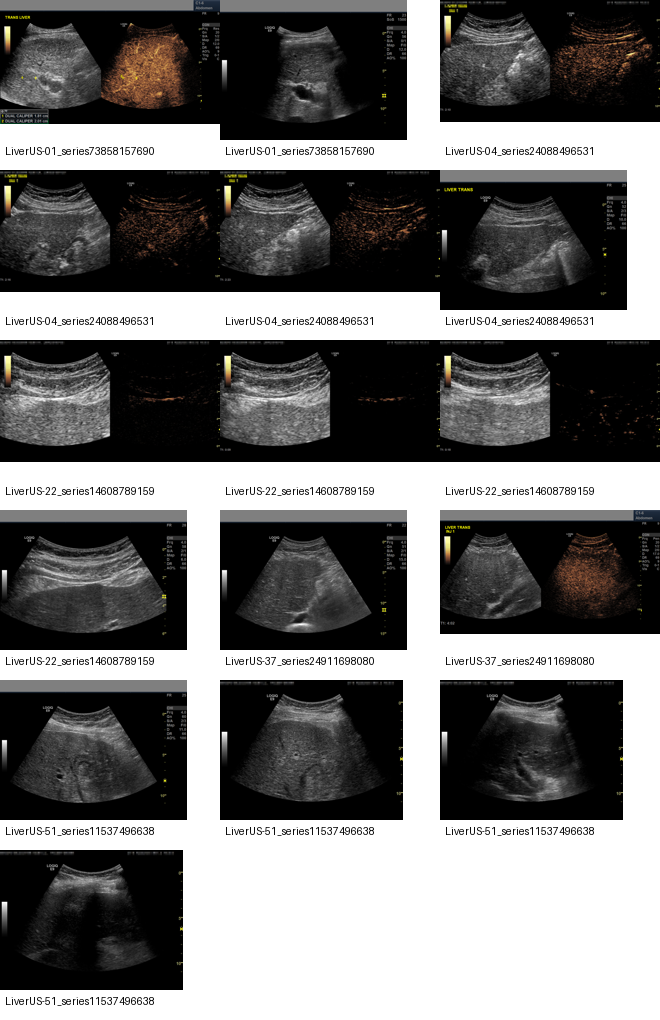

In [22]:
from PIL import Image, ImageDraw
import math

png_files = sorted(PILOT_FRAMES_DIR.glob("*.png"))

print("PNG files:", len(png_files))

thumb_w, thumb_h = 220, 170
cols = 3
rows = math.ceil(len(png_files) / cols)

canvas = Image.new("RGB", (cols * thumb_w, rows * thumb_h), "white")
draw = ImageDraw.Draw(canvas)

for i, p in enumerate(png_files):
    img = Image.open(p).convert("RGB")
    img.thumbnail((thumb_w, thumb_h - 30))

    x = (i % cols) * thumb_w
    y = (i // cols) * thumb_h

    canvas.paste(img, (x, y))
    draw.text((x + 5, y + thumb_h - 25), p.name[:28], fill=(0, 0, 0))

contact_sheet_path = QC_DIR / "pilot_frames_contact_sheet.png"
canvas.save(contact_sheet_path)

print("Saved:", contact_sheet_path)

display(canvas)

In [23]:
series_summary
pilot_log_df

,PatientID,SeriesInstanceUID,source_file,n_saved_frames,saved_paths,status,error
0,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
1,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
2,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
3,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,/kaggle/working/liver_digital_twin/data/raw_tc...,3,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
4,LiverUS-22,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
5,LiverUS-22,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,/kaggle/working/liver_digital_twin/data/raw_tc...,3,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
6,LiverUS-37,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
7,LiverUS-37,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
8,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
9,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,/kaggle/working/liver_digital_twin/data/raw_tc...,3,/kaggle/working/liver_digital_twin/data/pilot_...,ok,


In [24]:
# Clean DICOM manifest: keep only real image DICOM files

dicom_manifest_df = pd.read_csv(MANIFEST_DIR / "dicom_manifest_sample.csv")

# Convert important columns
for col in ["Rows", "Columns", "NumberOfFrames", "InstanceNumber"]:
    if col in dicom_manifest_df.columns:
        dicom_manifest_df[col] = pd.to_numeric(dicom_manifest_df[col], errors="coerce")

# A valid image DICOM should have:
# parse_ok=True, Modality present, Rows/Columns present, TransferSyntaxUID present
valid_dicom_df = dicom_manifest_df[
    (dicom_manifest_df["parse_ok"] == True) &
    (dicom_manifest_df["Modality"].notna()) &
    (dicom_manifest_df["Rows"].notna()) &
    (dicom_manifest_df["Columns"].notna()) &
    (dicom_manifest_df["TransferSyntaxUID"].notna())
].copy()

invalid_dicom_df = dicom_manifest_df[~dicom_manifest_df.index.isin(valid_dicom_df.index)].copy()

print("Original manifest rows:", len(dicom_manifest_df))
print("Valid image DICOM rows:", len(valid_dicom_df))
print("Excluded rows:", len(invalid_dicom_df))

display(invalid_dicom_df[["filename", "parse_ok", "Modality", "Rows", "Columns", "TransferSyntaxUID", "error"]])

valid_path = MANIFEST_DIR / "dicom_manifest_clean_sample.csv"
invalid_path = MANIFEST_DIR / "excluded_non_image_files_sample.csv"

valid_dicom_df.to_csv(valid_path, index=False)
invalid_dicom_df.to_csv(invalid_path, index=False)

print("Saved clean manifest:", valid_path)
print("Saved excluded files:", invalid_path)

Original manifest rows: 104
Valid image DICOM rows: 99
Excluded rows: 5


,filename,parse_ok,Modality,Rows,Columns,TransferSyntaxUID,error
9,LICENSE,True,NaN,NaN,NaN,NaN,NaN
22,LICENSE,True,NaN,NaN,NaN,NaN,NaN
49,LICENSE,True,NaN,NaN,NaN,NaN,NaN
93,LICENSE,True,NaN,NaN,NaN,NaN,NaN
103,LICENSE,True,NaN,NaN,NaN,NaN,NaN


Saved clean manifest: /kaggle/working/liver_digital_twin/data/manifests/dicom_manifest_clean_sample.csv
Saved excluded files: /kaggle/working/liver_digital_twin/data/manifests/excluded_non_image_files_sample.csv


In [25]:
def classify_image_type(row):
    nframes = row.get("NumberOfFrames", 1)
    
    if pd.isna(nframes):
        nframes = 1
    
    nframes = int(nframes)
    
    if nframes <= 1:
        return "single_frame_image"
    else:
        return "multi_frame_cine_loop"


def classify_ultrasound_role_v0(row):
    """
    First-pass heuristic only.
    Because SeriesDescription is empty, we will not hard-label B-mode vs CEUS yet.
    """
    nframes = row.get("NumberOfFrames", 1)
    rows = row.get("Rows", None)
    cols = row.get("Columns", None)
    
    if pd.isna(nframes):
        nframes = 1
    
    nframes = int(nframes)
    
    if nframes > 1:
        return "ceus_cine_candidate"
    
    if nframes == 1:
        return "bmode_or_static_us_candidate"
    
    return "unknown"


valid_dicom_df["image_type"] = valid_dicom_df.apply(classify_image_type, axis=1)
valid_dicom_df["ultrasound_role_v0"] = valid_dicom_df.apply(classify_ultrasound_role_v0, axis=1)

display(
    valid_dicom_df[
        ["PatientID", "filename", "Rows", "Columns", "NumberOfFrames", "image_type", "ultrasound_role_v0"]
    ].head(20)
)

print("Image type counts:")
display(valid_dicom_df["image_type"].value_counts())

print("Ultrasound role v0 counts:")
display(valid_dicom_df["ultrasound_role_v0"].value_counts())

valid_dicom_df.to_csv(MANIFEST_DIR / "dicom_manifest_clean_sample.csv", index=False)

,PatientID,filename,Rows,Columns,NumberOfFrames,image_type,ultrasound_role_v0
0,LiverUS-51,00000001.dcm,720.0,960.0,1,single_frame_image,bmode_or_static_us_candidate
1,LiverUS-51,00000002.dcm,720.0,960.0,1,single_frame_image,bmode_or_static_us_candidate
2,LiverUS-51,00000003.dcm,720.0,960.0,1,single_frame_image,bmode_or_static_us_candidate
3,LiverUS-51,00000004.dcm,720.0,960.0,1,single_frame_image,bmode_or_static_us_candidate
4,LiverUS-51,00000005.dcm,649.0,1170.0,268,multi_frame_cine_loop,ceus_cine_candidate
5,LiverUS-51,00000006.dcm,649.0,1170.0,420,multi_frame_cine_loop,ceus_cine_candidate
6,LiverUS-51,00000007.dcm,649.0,850.0,93,multi_frame_cine_loop,ceus_cine_candidate
7,LiverUS-51,00000008.dcm,649.0,850.0,119,multi_frame_cine_loop,ceus_cine_candidate
8,LiverUS-51,00000009.dcm,649.0,850.0,57,multi_frame_cine_loop,ceus_cine_candidate
10,LiverUS-22,00000001.dcm,720.0,960.0,1,single_frame_image,bmode_or_static_us_candidate


Image type counts:


image_type
single_frame_image       65
multi_frame_cine_loop    34
Name: count, dtype: int64

Ultrasound role v0 counts:


ultrasound_role_v0
bmode_or_static_us_candidate    65
ceus_cine_candidate             34
Name: count, dtype: int64

In [26]:
series_level_summary = (
    valid_dicom_df
    .groupby(["PatientID", "SeriesInstanceUID"], dropna=False)
    .agg(
        n_dicom_files=("abs_path", "count"),
        n_single_frame=("image_type", lambda x: (x == "single_frame_image").sum()),
        n_cine_loops=("image_type", lambda x: (x == "multi_frame_cine_loop").sum()),
        min_rows=("Rows", "min"),
        max_rows=("Rows", "max"),
        min_cols=("Columns", "min"),
        max_cols=("Columns", "max"),
        max_frames=("NumberOfFrames", "max"),
        manufacturer=("Manufacturer", "first"),
        model=("ManufacturerModelName", "first"),
    )
    .reset_index()
)

display(series_level_summary)

series_summary_path = MANIFEST_DIR / "series_level_summary_sample.csv"
series_level_summary.to_csv(series_summary_path, index=False)

print("Saved:", series_summary_path)

,PatientID,SeriesInstanceUID,n_dicom_files,n_single_frame,n_cine_loops,min_rows,max_rows,min_cols,max_cols,max_frames,manufacturer,model
0,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,9,7,2,649.0,720.0,960.0,1280.0,163,GE Healthcare,LOGIQE9
1,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,26,20,6,649.0,720.0,850.0,1280.0,205,GE Healthcare,LOGIQE9
2,LiverUS-22,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,12,4,8,649.0,720.0,850.0,1170.0,424,GE Healthcare,LOGIQE9
3,LiverUS-37,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,43,30,13,649.0,720.0,850.0,1280.0,321,GE Healthcare,LOGIQE9
4,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,9,4,5,649.0,720.0,850.0,1170.0,420,GE Healthcare,LOGIQE9


Saved: /kaggle/working/liver_digital_twin/data/manifests/series_level_summary_sample.csv


In [27]:
df = valid_dicom_df.copy()

df["InstanceNumber"] = pd.to_numeric(df["InstanceNumber"], errors="coerce")
df["NumberOfFrames"] = pd.to_numeric(df["NumberOfFrames"], errors="coerce").fillna(1)

df = df.sort_values(["PatientID", "SeriesInstanceUID", "image_type", "InstanceNumber", "filename"])

selected_rows = []

for (patient_id, series_uid), g in df.groupby(["PatientID", "SeriesInstanceUID"], dropna=False):
    g = g.reset_index(drop=True)
    
    # Pick one single-frame image if available
    single_g = g[g["image_type"] == "single_frame_image"].reset_index(drop=True)
    if len(single_g) > 0:
        selected_rows.append(single_g.iloc[0])
    
    # Pick one cine-loop if available
    cine_g = g[g["image_type"] == "multi_frame_cine_loop"].reset_index(drop=True)
    if len(cine_g) > 0:
        selected_rows.append(cine_g.iloc[0])

selected_preview_df = pd.DataFrame(selected_rows).reset_index(drop=True)

print("Selected valid DICOM files for preview:", len(selected_preview_df))

display(selected_preview_df[[
    "PatientID",
    "filename",
    "Rows",
    "Columns",
    "NumberOfFrames",
    "image_type",
    "ultrasound_role_v0"
]])

Selected valid DICOM files for preview: 10


,PatientID,filename,Rows,Columns,NumberOfFrames,image_type,ultrasound_role_v0
0,LiverUS-01,00000004.dcm,720.0,960.0,1,single_frame_image,bmode_or_static_us_candidate
1,LiverUS-01,00000009.dcm,649.0,1170.0,163,multi_frame_cine_loop,ceus_cine_candidate
2,LiverUS-04,00000007.dcm,720.0,960.0,1,single_frame_image,bmode_or_static_us_candidate
3,LiverUS-04,00000024.dcm,649.0,850.0,88,multi_frame_cine_loop,ceus_cine_candidate
4,LiverUS-22,00000011.dcm,720.0,960.0,1,single_frame_image,bmode_or_static_us_candidate
5,LiverUS-22,00000006.dcm,649.0,850.0,106,multi_frame_cine_loop,ceus_cine_candidate
6,LiverUS-37,00000025.dcm,720.0,960.0,1,single_frame_image,bmode_or_static_us_candidate
7,LiverUS-37,00000006.dcm,649.0,850.0,78,multi_frame_cine_loop,ceus_cine_candidate
8,LiverUS-51,00000002.dcm,720.0,960.0,1,single_frame_image,bmode_or_static_us_candidate
9,LiverUS-51,00000007.dcm,649.0,850.0,93,multi_frame_cine_loop,ceus_cine_candidate


In [28]:
# Optional: clear old pilot PNGs before clean extraction
for p in PILOT_FRAMES_DIR.glob("*.png"):
    p.unlink()

print("Cleared old pilot frames.")
print("Current PNG count:", len(list(PILOT_FRAMES_DIR.glob("*.png"))))

Cleared old pilot frames.
Current PNG count: 0


In [29]:
pilot_log = []

for i, row in tqdm(selected_preview_df.iterrows(), total=len(selected_preview_df)):
    try:
        patient_id = str(row["PatientID"]) if pd.notna(row["PatientID"]) else "unknown_patient"
        series_short = str(row["SeriesInstanceUID"]).split(".")[-1]
        filename_stem = Path(row["filename"]).stem
        
        out_prefix = f"{patient_id}_series{series_short}_{row['image_type']}_{filename_stem}"
        
        saved_paths = extract_one_dicom_preview(
            path=row["abs_path"],
            out_prefix=out_prefix,
            number_of_frames=row["NumberOfFrames"]
        )
        
        pilot_log.append({
            "PatientID": patient_id,
            "SeriesInstanceUID": row["SeriesInstanceUID"],
            "filename": row["filename"],
            "image_type": row["image_type"],
            "ultrasound_role_v0": row["ultrasound_role_v0"],
            "Rows": row["Rows"],
            "Columns": row["Columns"],
            "NumberOfFrames": row["NumberOfFrames"],
            "source_file": row["abs_path"],
            "n_saved_frames": len(saved_paths),
            "saved_paths": "|".join(saved_paths),
            "status": "ok",
            "error": ""
        })
        
    except Exception as e:
        pilot_log.append({
            "PatientID": row.get("PatientID", None),
            "SeriesInstanceUID": row.get("SeriesInstanceUID", None),
            "filename": row.get("filename", None),
            "image_type": row.get("image_type", None),
            "ultrasound_role_v0": row.get("ultrasound_role_v0", None),
            "Rows": row.get("Rows", None),
            "Columns": row.get("Columns", None),
            "NumberOfFrames": row.get("NumberOfFrames", None),
            "source_file": row.get("abs_path", None),
            "n_saved_frames": 0,
            "saved_paths": "",
            "status": "error",
            "error": str(e)
        })

pilot_log_df = pd.DataFrame(pilot_log)

display(pilot_log_df)

pilot_log_path = MANIFEST_DIR / "pilot_frame_extraction_log_clean.csv"
pilot_log_df.to_csv(pilot_log_path, index=False)

print("Saved:", pilot_log_path)
print("Number of PNGs:", len(list(PILOT_FRAMES_DIR.glob("*.png"))))

  0%|          | 0/10 [00:00<?, ?it/s]

,PatientID,SeriesInstanceUID,filename,image_type,ultrasound_role_v0,Rows,Columns,NumberOfFrames,source_file,n_saved_frames,saved_paths,status,error
0,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,00000004.dcm,single_frame_image,bmode_or_static_us_candidate,720.0,960.0,1,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
1,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,00000009.dcm,multi_frame_cine_loop,ceus_cine_candidate,649.0,1170.0,163,/kaggle/working/liver_digital_twin/data/raw_tc...,3,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
2,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,00000007.dcm,single_frame_image,bmode_or_static_us_candidate,720.0,960.0,1,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
3,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,00000024.dcm,multi_frame_cine_loop,ceus_cine_candidate,649.0,850.0,88,/kaggle/working/liver_digital_twin/data/raw_tc...,3,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
4,LiverUS-22,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,00000011.dcm,single_frame_image,bmode_or_static_us_candidate,720.0,960.0,1,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
5,LiverUS-22,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,00000006.dcm,multi_frame_cine_loop,ceus_cine_candidate,649.0,850.0,106,/kaggle/working/liver_digital_twin/data/raw_tc...,3,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
6,LiverUS-37,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,00000025.dcm,single_frame_image,bmode_or_static_us_candidate,720.0,960.0,1,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
7,LiverUS-37,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,00000006.dcm,multi_frame_cine_loop,ceus_cine_candidate,649.0,850.0,78,/kaggle/working/liver_digital_twin/data/raw_tc...,3,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
8,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000002.dcm,single_frame_image,bmode_or_static_us_candidate,720.0,960.0,1,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
9,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000007.dcm,multi_frame_cine_loop,ceus_cine_candidate,649.0,850.0,93,/kaggle/working/liver_digital_twin/data/raw_tc...,3,/kaggle/working/liver_digital_twin/data/pilot_...,ok,


Saved: /kaggle/working/liver_digital_twin/data/manifests/pilot_frame_extraction_log_clean.csv
Number of PNGs: 20


PNG files: 20
Saved: /kaggle/working/liver_digital_twin/data/qc/pilot_frames_contact_sheet_clean.png


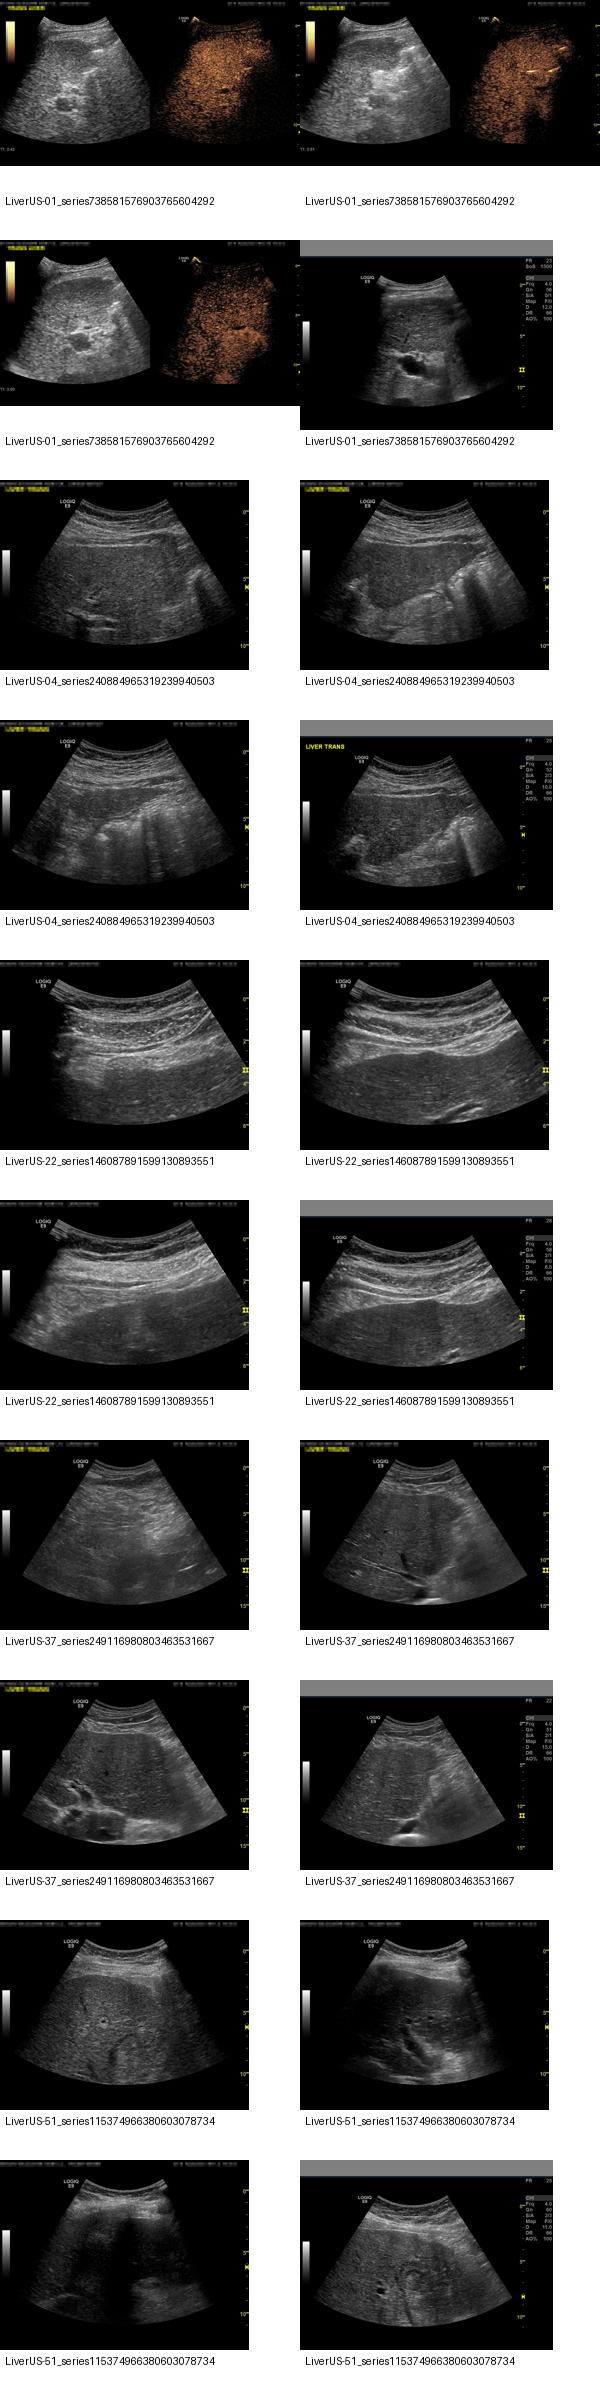

In [30]:
from PIL import Image, ImageDraw, ImageFont
import math

png_files = sorted(PILOT_FRAMES_DIR.glob("*.png"))

print("PNG files:", len(png_files))

thumb_w, thumb_h = 300, 240
cols = 2
rows = math.ceil(len(png_files) / cols)

canvas = Image.new("RGB", (cols * thumb_w, rows * thumb_h), "white")
draw = ImageDraw.Draw(canvas)

for i, p in enumerate(png_files):
    img = Image.open(p).convert("RGB")
    img.thumbnail((thumb_w, thumb_h - 50))

    x = (i % cols) * thumb_w
    y = (i // cols) * thumb_h

    canvas.paste(img, (x, y))
    
    label = p.name[:38]
    draw.text((x + 5, y + thumb_h - 45), label, fill=(0, 0, 0))

contact_sheet_path = QC_DIR / "pilot_frames_contact_sheet_clean.png"
canvas.save(contact_sheet_path)

print("Saved:", contact_sheet_path)

display(canvas)

In [31]:
series_level_summary
pilot_log_df

,PatientID,SeriesInstanceUID,filename,image_type,ultrasound_role_v0,Rows,Columns,NumberOfFrames,source_file,n_saved_frames,saved_paths,status,error
0,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,00000004.dcm,single_frame_image,bmode_or_static_us_candidate,720.0,960.0,1,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
1,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,00000009.dcm,multi_frame_cine_loop,ceus_cine_candidate,649.0,1170.0,163,/kaggle/working/liver_digital_twin/data/raw_tc...,3,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
2,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,00000007.dcm,single_frame_image,bmode_or_static_us_candidate,720.0,960.0,1,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
3,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,00000024.dcm,multi_frame_cine_loop,ceus_cine_candidate,649.0,850.0,88,/kaggle/working/liver_digital_twin/data/raw_tc...,3,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
4,LiverUS-22,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,00000011.dcm,single_frame_image,bmode_or_static_us_candidate,720.0,960.0,1,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
5,LiverUS-22,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,00000006.dcm,multi_frame_cine_loop,ceus_cine_candidate,649.0,850.0,106,/kaggle/working/liver_digital_twin/data/raw_tc...,3,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
6,LiverUS-37,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,00000025.dcm,single_frame_image,bmode_or_static_us_candidate,720.0,960.0,1,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
7,LiverUS-37,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,00000006.dcm,multi_frame_cine_loop,ceus_cine_candidate,649.0,850.0,78,/kaggle/working/liver_digital_twin/data/raw_tc...,3,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
8,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000002.dcm,single_frame_image,bmode_or_static_us_candidate,720.0,960.0,1,/kaggle/working/liver_digital_twin/data/raw_tc...,1,/kaggle/working/liver_digital_twin/data/pilot_...,ok,
9,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,00000007.dcm,multi_frame_cine_loop,ceus_cine_candidate,649.0,850.0,93,/kaggle/working/liver_digital_twin/data/raw_tc...,3,/kaggle/working/liver_digital_twin/data/pilot_...,ok,


In [32]:
# Create a more informative file-level foundation manifest

foundation_df = valid_dicom_df.copy()

for col in ["Rows", "Columns", "NumberOfFrames", "InstanceNumber"]:
    foundation_df[col] = pd.to_numeric(foundation_df[col], errors="coerce")

def classify_layout_v1(row):
    rows = row.get("Rows", None)
    cols = row.get("Columns", None)
    nframes = row.get("NumberOfFrames", 1)

    if pd.isna(nframes):
        nframes = 1
    if pd.isna(cols):
        return "unknown_layout"

    nframes = int(nframes)
    cols = int(cols)

    # From visual QC: wide frames are likely dual-panel B-mode + CEUS
    if cols >= 1100:
        if nframes > 1:
            return "dual_panel_cine_candidate"
        else:
            return "wide_static_candidate"

    if nframes > 1:
        return "single_panel_cine_candidate"

    return "single_panel_static_candidate"


def classify_role_v1(row):
    layout = row["layout_v1"]
    nframes = row.get("NumberOfFrames", 1)

    if pd.isna(nframes):
        nframes = 1
    nframes = int(nframes)

    if layout == "dual_panel_cine_candidate":
        return "ceus_bmode_dual_panel_cine_candidate"

    if layout == "single_panel_cine_candidate":
        return "cine_ultrasound_candidate"

    if layout == "single_panel_static_candidate":
        return "static_bmode_candidate"

    if layout == "wide_static_candidate":
        return "wide_static_ultrasound_candidate"

    return "unknown"


foundation_df["layout_v1"] = foundation_df.apply(classify_layout_v1, axis=1)
foundation_df["ultrasound_role_v1"] = foundation_df.apply(classify_role_v1, axis=1)

display(
    foundation_df[
        [
            "PatientID",
            "filename",
            "Rows",
            "Columns",
            "NumberOfFrames",
            "image_type",
            "layout_v1",
            "ultrasound_role_v1",
        ]
    ].head(30)
)

print("Layout counts:")
display(foundation_df["layout_v1"].value_counts())

print("Role counts:")
display(foundation_df["ultrasound_role_v1"].value_counts())

foundation_manifest_path = MANIFEST_DIR / "file_level_foundation_manifest_sample_v0_1.csv"
foundation_df.to_csv(foundation_manifest_path, index=False)

print("Saved:", foundation_manifest_path)

,PatientID,filename,Rows,Columns,NumberOfFrames,image_type,layout_v1,ultrasound_role_v1
0,LiverUS-51,00000001.dcm,720.0,960.0,1,single_frame_image,single_panel_static_candidate,static_bmode_candidate
1,LiverUS-51,00000002.dcm,720.0,960.0,1,single_frame_image,single_panel_static_candidate,static_bmode_candidate
2,LiverUS-51,00000003.dcm,720.0,960.0,1,single_frame_image,single_panel_static_candidate,static_bmode_candidate
3,LiverUS-51,00000004.dcm,720.0,960.0,1,single_frame_image,single_panel_static_candidate,static_bmode_candidate
4,LiverUS-51,00000005.dcm,649.0,1170.0,268,multi_frame_cine_loop,dual_panel_cine_candidate,ceus_bmode_dual_panel_cine_candidate
5,LiverUS-51,00000006.dcm,649.0,1170.0,420,multi_frame_cine_loop,dual_panel_cine_candidate,ceus_bmode_dual_panel_cine_candidate
6,LiverUS-51,00000007.dcm,649.0,850.0,93,multi_frame_cine_loop,single_panel_cine_candidate,cine_ultrasound_candidate
7,LiverUS-51,00000008.dcm,649.0,850.0,119,multi_frame_cine_loop,single_panel_cine_candidate,cine_ultrasound_candidate
8,LiverUS-51,00000009.dcm,649.0,850.0,57,multi_frame_cine_loop,single_panel_cine_candidate,cine_ultrasound_candidate
10,LiverUS-22,00000001.dcm,720.0,960.0,1,single_frame_image,single_panel_static_candidate,static_bmode_candidate


Layout counts:


layout_v1
wide_static_candidate            41
dual_panel_cine_candidate        25
single_panel_static_candidate    24
single_panel_cine_candidate       9
Name: count, dtype: int64

Role counts:


ultrasound_role_v1
wide_static_ultrasound_candidate        41
ceus_bmode_dual_panel_cine_candidate    25
static_bmode_candidate                  24
cine_ultrasound_candidate                9
Name: count, dtype: int64

Saved: /kaggle/working/liver_digital_twin/data/manifests/file_level_foundation_manifest_sample_v0_1.csv


In [33]:
pairing_candidates_v0 = (
    foundation_df
    .groupby(["PatientID", "StudyInstanceUID", "SeriesInstanceUID"], dropna=False)
    .agg(
        n_files=("abs_path", "count"),
        n_static_bmode_candidates=("ultrasound_role_v1", lambda x: (x == "static_bmode_candidate").sum()),
        n_dual_panel_cine_candidates=("ultrasound_role_v1", lambda x: (x == "ceus_bmode_dual_panel_cine_candidate").sum()),
        n_single_panel_cine_candidates=("ultrasound_role_v1", lambda x: (x == "cine_ultrasound_candidate").sum()),
        min_rows=("Rows", "min"),
        max_rows=("Rows", "max"),
        min_cols=("Columns", "min"),
        max_cols=("Columns", "max"),
        max_frames=("NumberOfFrames", "max"),
        manufacturer=("Manufacturer", "first"),
        model=("ManufacturerModelName", "first"),
    )
    .reset_index()
)

def assign_pairing_status(row):
    if row["n_static_bmode_candidates"] > 0 and row["n_dual_panel_cine_candidates"] > 0:
        return "static_bmode_plus_dual_panel_ceus_candidate"

    if row["n_static_bmode_candidates"] > 0 and row["n_single_panel_cine_candidates"] > 0:
        return "static_bmode_plus_cine_candidate"

    if row["n_dual_panel_cine_candidates"] > 0:
        return "dual_panel_cine_only_candidate"

    if row["n_static_bmode_candidates"] > 0:
        return "static_only_candidate"

    return "needs_manual_qc"

pairing_candidates_v0["pairing_status_v0"] = pairing_candidates_v0.apply(assign_pairing_status, axis=1)

display(pairing_candidates_v0)

pairing_path = MANIFEST_DIR / "pairing_candidates_sample_v0.csv"
pairing_candidates_v0.to_csv(pairing_path, index=False)

print("Saved:", pairing_path)

,PatientID,StudyInstanceUID,SeriesInstanceUID,n_files,n_static_bmode_candidates,n_dual_panel_cine_candidates,n_single_panel_cine_candidates,min_rows,max_rows,min_cols,max_cols,max_frames,manufacturer,model,pairing_status_v0
0,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.272546201471...,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,9,3,2,0,649.0,720.0,960.0,1280.0,163,GE Healthcare,LOGIQE9,static_bmode_plus_dual_panel_ceus_candidate
1,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.279513797246...,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,26,7,4,2,649.0,720.0,850.0,1280.0,205,GE Healthcare,LOGIQE9,static_bmode_plus_dual_panel_ceus_candidate
2,LiverUS-22,1.3.6.1.4.1.14519.5.2.1.1188.2803.222440931622...,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,12,4,6,2,649.0,720.0,850.0,1170.0,424,GE Healthcare,LOGIQE9,static_bmode_plus_dual_panel_ceus_candidate
3,LiverUS-37,1.3.6.1.4.1.14519.5.2.1.1188.2803.218426755577...,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,43,6,11,2,649.0,720.0,850.0,1280.0,321,GE Healthcare,LOGIQE9,static_bmode_plus_dual_panel_ceus_candidate
4,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,9,4,2,3,649.0,720.0,850.0,1170.0,420,GE Healthcare,LOGIQE9,static_bmode_plus_dual_panel_ceus_candidate


Saved: /kaggle/working/liver_digital_twin/data/manifests/pairing_candidates_sample_v0.csv


In [34]:
from datetime import datetime

qc_report_path = QC_DIR / "week1_sample_qc_report.md"

report = f"""# Week 1 Sample QC Report

## Project
Ultrasound Data Foundation for TCIA B-mode and CEUS Liver Collection

## Environment
Platform: Kaggle Notebook  
Raw data source: TCIA NBIA API  
Collection: {COLLECTION}

## Generated at
{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

## Sample download summary
- Total TCIA series available: {len(series_df)}
- Downloaded sample series: {len(sample_series)}
- Raw files indexed: {len(raw_index_df)}
- DICOM candidate files before cleaning: {len(dicom_candidates)}
- Valid image DICOM files after cleaning: {len(foundation_df)}
- Excluded non-image files: {len(invalid_dicom_df)}

## DICOM metadata parsing
- Parsed DICOM headers successfully: {int(dicom_manifest_df["parse_ok"].sum())}
- Failed DICOM header parses: {int((~dicom_manifest_df["parse_ok"]).sum())}

## Image type summary
{foundation_df["image_type"].value_counts().to_string()}

## Layout summary
{foundation_df["layout_v1"].value_counts().to_string()}

## Ultrasound role summary
{foundation_df["ultrasound_role_v1"].value_counts().to_string()}

## Series-level summary
- Unique patients: {foundation_df["PatientID"].nunique()}
- Unique studies: {foundation_df["StudyInstanceUID"].nunique()}
- Unique series: {foundation_df["SeriesInstanceUID"].nunique()}
- Scanner manufacturer: {foundation_df["Manufacturer"].dropna().unique().tolist()}
- Scanner model: {foundation_df["ManufacturerModelName"].dropna().unique().tolist()}

## Pilot frame extraction
- Selected preview DICOM files: {len(selected_preview_df)}
- Extracted PNG preview frames: {len(list(PILOT_FRAMES_DIR.glob("*.png")))}
- Pilot extraction log: {pilot_log_path}
- Contact sheet: {QC_DIR / "pilot_frames_contact_sheet_clean.png"}

## Interpretation
This sample confirms that the TCIA B-mode-and-CEUS-Liver collection can be accessed directly from Kaggle through the TCIA NBIA API and processed inside /kaggle/working without local download.

The sample contains both single-frame ultrasound images and multi-frame cine loops. Visual QC suggests that some cine frames may contain dual-panel layouts with B-mode and CEUS displayed side by side. Therefore, later stages should include visual QC and possible panel-splitting/cropping before model training.

## Current status
Week 1 data foundation sample pipeline is working.

## Next steps
1. Inspect dual-panel cine candidates visually.
2. Add panel-splitting logic for wide frames if confirmed.
3. Build a more systematic sampling strategy for downloading smaller series first.
4. Expand from 5 sample series to a larger controlled batch.
5. Prepare MONAI-compatible dataset records after pairing/cropping rules are confirmed.
"""

qc_report_path.write_text(report, encoding="utf-8")

print("Saved QC report:", qc_report_path)
print(report)

Saved QC report: /kaggle/working/liver_digital_twin/data/qc/week1_sample_qc_report.md
# Week 1 Sample QC Report

## Project
Ultrasound Data Foundation for TCIA B-mode and CEUS Liver Collection

## Environment
Platform: Kaggle Notebook  
Raw data source: TCIA NBIA API  
Collection: B-mode-and-CEUS-Liver

## Generated at
2026-06-29 19:19:02

## Sample download summary
- Total TCIA series available: 120
- Downloaded sample series: 5
- Raw files indexed: 104
- DICOM candidate files before cleaning: 104
- Valid image DICOM files after cleaning: 99
- Excluded non-image files: 5

## DICOM metadata parsing
- Parsed DICOM headers successfully: 104
- Failed DICOM header parses: 0

## Image type summary
image_type
single_frame_image       65
multi_frame_cine_loop    34

## Layout summary
layout_v1
wide_static_candidate            41
dual_panel_cine_candidate        25
single_panel_static_candidate    24
single_panel_cine_candidate       9

## Ultrasound role summary
ultrasound_role_v1
wide_static

In [35]:
foundation_df["layout_v1"].value_counts()
pairing_candidates_v0

,PatientID,StudyInstanceUID,SeriesInstanceUID,n_files,n_static_bmode_candidates,n_dual_panel_cine_candidates,n_single_panel_cine_candidates,min_rows,max_rows,min_cols,max_cols,max_frames,manufacturer,model,pairing_status_v0
0,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.272546201471...,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,9,3,2,0,649.0,720.0,960.0,1280.0,163,GE Healthcare,LOGIQE9,static_bmode_plus_dual_panel_ceus_candidate
1,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.279513797246...,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,26,7,4,2,649.0,720.0,850.0,1280.0,205,GE Healthcare,LOGIQE9,static_bmode_plus_dual_panel_ceus_candidate
2,LiverUS-22,1.3.6.1.4.1.14519.5.2.1.1188.2803.222440931622...,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,12,4,6,2,649.0,720.0,850.0,1170.0,424,GE Healthcare,LOGIQE9,static_bmode_plus_dual_panel_ceus_candidate
3,LiverUS-37,1.3.6.1.4.1.14519.5.2.1.1188.2803.218426755577...,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,43,6,11,2,649.0,720.0,850.0,1280.0,321,GE Healthcare,LOGIQE9,static_bmode_plus_dual_panel_ceus_candidate
4,LiverUS-51,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,9,4,2,3,649.0,720.0,850.0,1170.0,420,GE Healthcare,LOGIQE9,static_bmode_plus_dual_panel_ceus_candidate


In [36]:
dual_panel_df = foundation_df[
    foundation_df["layout_v1"] == "dual_panel_cine_candidate"
].copy()

dual_panel_df["NumberOfFrames"] = pd.to_numeric(
    dual_panel_df["NumberOfFrames"], errors="coerce"
).fillna(1)

dual_panel_df = dual_panel_df.sort_values(
    ["PatientID", "SeriesInstanceUID", "InstanceNumber", "filename"]
).reset_index(drop=True)

print("Dual-panel cine candidate files:", len(dual_panel_df))

display(
    dual_panel_df[
        [
            "PatientID",
            "filename",
            "Rows",
            "Columns",
            "NumberOfFrames",
            "layout_v1",
            "ultrasound_role_v1",
        ]
    ].head(20)
)

Dual-panel cine candidate files: 25


,PatientID,filename,Rows,Columns,NumberOfFrames,layout_v1,ultrasound_role_v1
0,LiverUS-01,00000009.dcm,649.0,1170.0,163,dual_panel_cine_candidate,ceus_bmode_dual_panel_cine_candidate
1,LiverUS-01,00000008.dcm,649.0,1170.0,105,dual_panel_cine_candidate,ceus_bmode_dual_panel_cine_candidate
2,LiverUS-04,00000005.dcm,649.0,1170.0,128,dual_panel_cine_candidate,ceus_bmode_dual_panel_cine_candidate
3,LiverUS-04,00000012.dcm,649.0,1170.0,101,dual_panel_cine_candidate,ceus_bmode_dual_panel_cine_candidate
4,LiverUS-04,00000018.dcm,649.0,1170.0,136,dual_panel_cine_candidate,ceus_bmode_dual_panel_cine_candidate
5,LiverUS-04,00000015.dcm,649.0,1170.0,205,dual_panel_cine_candidate,ceus_bmode_dual_panel_cine_candidate
6,LiverUS-22,00000003.dcm,649.0,1170.0,188,dual_panel_cine_candidate,ceus_bmode_dual_panel_cine_candidate
7,LiverUS-22,00000005.dcm,649.0,1170.0,424,dual_panel_cine_candidate,ceus_bmode_dual_panel_cine_candidate
8,LiverUS-22,00000007.dcm,649.0,1170.0,165,dual_panel_cine_candidate,ceus_bmode_dual_panel_cine_candidate
9,LiverUS-22,00000009.dcm,649.0,1170.0,146,dual_panel_cine_candidate,ceus_bmode_dual_panel_cine_candidate


In [37]:
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
from pydicom.pixels import pixel_array
from tqdm.auto import tqdm

SPLIT_PREVIEW_DIR = PROJECT_DIR / "data" / "panel_split_preview"
SPLIT_PREVIEW_DIR.mkdir(parents=True, exist_ok=True)

def split_dual_panel_frame(arr):
    """
    Split a dual-panel ultrasound frame into left and right halves.
    Usually left = B-mode, right = CEUS.
    This is a first-pass QC split only.
    """
    arr = normalize_to_uint8(arr)

    if arr.ndim == 2:
        h, w = arr.shape
        mid = w // 2
        left = arr[:, :mid]
        right = arr[:, mid:]
        return left, right

    if arr.ndim == 3:
        h, w, c = arr.shape
        mid = w // 2
        left = arr[:, :mid, :]
        right = arr[:, mid:, :]
        return left, right

    raise ValueError(f"Unexpected frame shape: {arr.shape}")


def save_panel_png(arr, out_path):
    arr = normalize_to_uint8(arr)

    if arr.ndim == 2:
        Image.fromarray(arr, mode="L").save(out_path)
    else:
        Image.fromarray(arr).save(out_path)


split_log = []

# خدي أول 5 ملفات dual-panel فقط للتجربة
preview_dual_rows = dual_panel_df.head(5)

for i, row in tqdm(preview_dual_rows.iterrows(), total=len(preview_dual_rows)):
    try:
        nframes = int(row["NumberOfFrames"])
        
        # اختار أول، نص، آخر frame
        frame_indices = sorted(set([0, nframes // 2, nframes - 1]))
        
        patient_id = str(row["PatientID"])
        series_short = str(row["SeriesInstanceUID"]).split(".")[-1]
        filename_stem = Path(row["filename"]).stem
        
        for frame_idx in frame_indices:
            arr = pixel_array(str(row["abs_path"]), index=frame_idx)
            left_panel, right_panel = split_dual_panel_frame(arr)
            
            base_name = f"{patient_id}_series{series_short}_{filename_stem}_frame{frame_idx:04d}"
            
            left_path = SPLIT_PREVIEW_DIR / f"{base_name}_LEFT_bmode_candidate.png"
            right_path = SPLIT_PREVIEW_DIR / f"{base_name}_RIGHT_ceus_candidate.png"
            
            save_panel_png(left_panel, left_path)
            save_panel_png(right_panel, right_path)
            
            split_log.append({
                "PatientID": patient_id,
                "SeriesInstanceUID": row["SeriesInstanceUID"],
                "filename": row["filename"],
                "frame_idx": frame_idx,
                "source_path": row["abs_path"],
                "left_panel_path": str(left_path),
                "right_panel_path": str(right_path),
                "status": "ok",
                "error": ""
            })
            
    except Exception as e:
        split_log.append({
            "PatientID": row.get("PatientID", None),
            "SeriesInstanceUID": row.get("SeriesInstanceUID", None),
            "filename": row.get("filename", None),
            "frame_idx": None,
            "source_path": row.get("abs_path", None),
            "left_panel_path": "",
            "right_panel_path": "",
            "status": "error",
            "error": str(e)
        })

split_log_df = pd.DataFrame(split_log)

display(split_log_df)

split_log_path = MANIFEST_DIR / "dual_panel_split_preview_log.csv"
split_log_df.to_csv(split_log_path, index=False)

print("Saved:", split_log_path)
print("Split preview images:", len(list(SPLIT_PREVIEW_DIR.glob('*.png'))))

  0%|          | 0/5 [00:00<?, ?it/s]

,PatientID,SeriesInstanceUID,filename,frame_idx,source_path,left_panel_path,right_panel_path,status,error
0,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,00000009.dcm,0,/kaggle/working/liver_digital_twin/data/raw_tc...,/kaggle/working/liver_digital_twin/data/panel_...,/kaggle/working/liver_digital_twin/data/panel_...,ok,
1,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,00000009.dcm,81,/kaggle/working/liver_digital_twin/data/raw_tc...,/kaggle/working/liver_digital_twin/data/panel_...,/kaggle/working/liver_digital_twin/data/panel_...,ok,
2,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,00000009.dcm,162,/kaggle/working/liver_digital_twin/data/raw_tc...,/kaggle/working/liver_digital_twin/data/panel_...,/kaggle/working/liver_digital_twin/data/panel_...,ok,
3,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,00000008.dcm,0,/kaggle/working/liver_digital_twin/data/raw_tc...,/kaggle/working/liver_digital_twin/data/panel_...,/kaggle/working/liver_digital_twin/data/panel_...,ok,
4,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,00000008.dcm,52,/kaggle/working/liver_digital_twin/data/raw_tc...,/kaggle/working/liver_digital_twin/data/panel_...,/kaggle/working/liver_digital_twin/data/panel_...,ok,
5,LiverUS-01,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,00000008.dcm,104,/kaggle/working/liver_digital_twin/data/raw_tc...,/kaggle/working/liver_digital_twin/data/panel_...,/kaggle/working/liver_digital_twin/data/panel_...,ok,
6,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,00000005.dcm,0,/kaggle/working/liver_digital_twin/data/raw_tc...,/kaggle/working/liver_digital_twin/data/panel_...,/kaggle/working/liver_digital_twin/data/panel_...,ok,
7,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,00000005.dcm,64,/kaggle/working/liver_digital_twin/data/raw_tc...,/kaggle/working/liver_digital_twin/data/panel_...,/kaggle/working/liver_digital_twin/data/panel_...,ok,
8,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,00000005.dcm,127,/kaggle/working/liver_digital_twin/data/raw_tc...,/kaggle/working/liver_digital_twin/data/panel_...,/kaggle/working/liver_digital_twin/data/panel_...,ok,
9,LiverUS-04,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,00000012.dcm,0,/kaggle/working/liver_digital_twin/data/raw_tc...,/kaggle/working/liver_digital_twin/data/panel_...,/kaggle/working/liver_digital_twin/data/panel_...,ok,


Saved: /kaggle/working/liver_digital_twin/data/manifests/dual_panel_split_preview_log.csv
Split preview images: 30


Split preview PNGs: 30
Saved: /kaggle/working/liver_digital_twin/data/qc/dual_panel_split_preview_contact_sheet.png


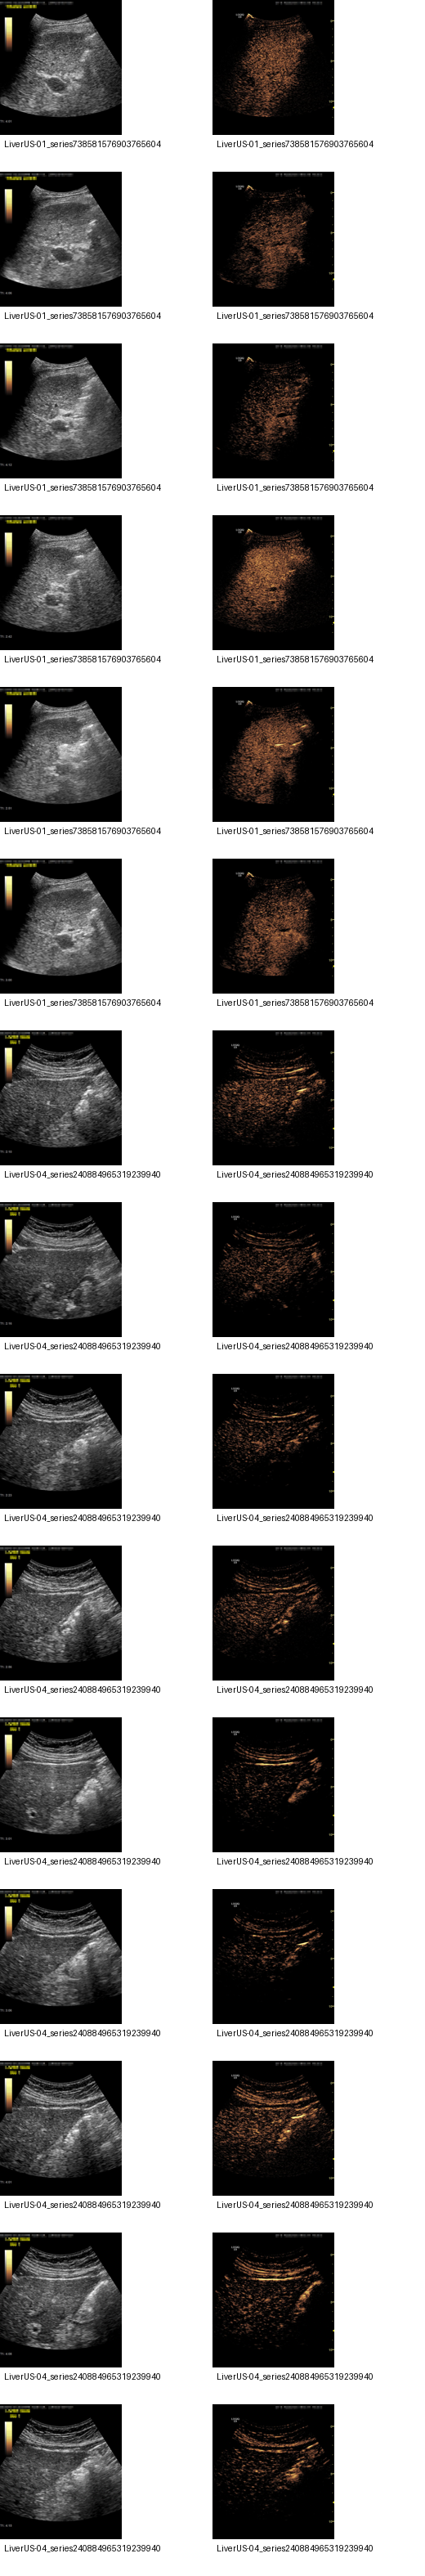

In [38]:
from PIL import Image, ImageDraw
import math

split_pngs = sorted(SPLIT_PREVIEW_DIR.glob("*.png"))

print("Split preview PNGs:", len(split_pngs))

thumb_w, thumb_h = 260, 210
cols = 2
rows = math.ceil(len(split_pngs) / cols)

canvas = Image.new("RGB", (cols * thumb_w, rows * thumb_h), "white")
draw = ImageDraw.Draw(canvas)

for i, p in enumerate(split_pngs):
    img = Image.open(p).convert("RGB")
    img.thumbnail((thumb_w, thumb_h - 45))

    x = (i % cols) * thumb_w
    y = (i // cols) * thumb_h

    canvas.paste(img, (x, y))
    draw.text((x + 5, y + thumb_h - 40), p.name[:35], fill=(0, 0, 0))

split_contact_sheet_path = QC_DIR / "dual_panel_split_preview_contact_sheet.png"
canvas.save(split_contact_sheet_path)

print("Saved:", split_contact_sheet_path)

display(canvas)

In [39]:
extra_report = f"""

## Dual-panel split preview

A first-pass dual-panel split preview was created for selected cine candidates.

- Dual-panel cine candidate files: {len(dual_panel_df)}
- Files used for split preview: {len(preview_dual_rows)}
- Split preview PNGs generated: {len(list(SPLIT_PREVIEW_DIR.glob("*.png")))}
- Split preview folder: {SPLIT_PREVIEW_DIR}
- Split preview contact sheet: {split_contact_sheet_path}
- Split log: {split_log_path}

Interpretation:
Visual QC confirms that some CEUS cine frames use a dual-panel layout. The left side is treated as a B-mode candidate and the right side as a CEUS candidate for preview purposes only. This split should be manually verified before being used as a final preprocessing rule.
"""

with open(qc_report_path, "a", encoding="utf-8") as f:
    f.write(extra_report)

print("Updated QC report:", qc_report_path)
print(extra_report)

Updated QC report: /kaggle/working/liver_digital_twin/data/qc/week1_sample_qc_report.md


## Dual-panel split preview

A first-pass dual-panel split preview was created for selected cine candidates.

- Dual-panel cine candidate files: 25
- Files used for split preview: 5
- Split preview PNGs generated: 30
- Split preview folder: /kaggle/working/liver_digital_twin/data/panel_split_preview
- Split preview contact sheet: /kaggle/working/liver_digital_twin/data/qc/dual_panel_split_preview_contact_sheet.png
- Split log: /kaggle/working/liver_digital_twin/data/manifests/dual_panel_split_preview_log.csv

Interpretation:
Visual QC confirms that some CEUS cine frames use a dual-panel layout. The left side is treated as a B-mode candidate and the right side as a CEUS candidate for preview purposes only. This split should be manually verified before being used as a final preprocessing rule.



In [40]:
from pathlib import Path
import pandas as pd

DELIVERABLES = {
    "TCIA series manifest": MANIFEST_DIR / "tcia_series_manifest.csv",
    "Selected sample series": MANIFEST_DIR / "selected_sample_series.csv",
    "Sample download log": MANIFEST_DIR / "sample_download_log.csv",
    "Raw file index": MANIFEST_DIR / "raw_file_index.csv",
    "DICOM smoke test": MANIFEST_DIR / "dicom_smoke_test.csv",
    "DICOM manifest sample": MANIFEST_DIR / "dicom_manifest_sample.csv",
    "Clean DICOM manifest": MANIFEST_DIR / "dicom_manifest_clean_sample.csv",
    "Excluded non-image files": MANIFEST_DIR / "excluded_non_image_files_sample.csv",
    "Series-level summary": MANIFEST_DIR / "series_level_summary_sample.csv",
    "File-level foundation manifest v0.1": MANIFEST_DIR / "file_level_foundation_manifest_sample_v0_1.csv",
    "Pairing candidates v0": MANIFEST_DIR / "pairing_candidates_sample_v0.csv",
    "Pilot extraction log": MANIFEST_DIR / "pilot_frame_extraction_log_clean.csv",
    "Dual-panel split preview log": MANIFEST_DIR / "dual_panel_split_preview_log.csv",
    "Pilot frames contact sheet": QC_DIR / "pilot_frames_contact_sheet_clean.png",
    "Dual-panel split contact sheet": QC_DIR / "dual_panel_split_preview_contact_sheet.png",
    "Week 1 QC report": QC_DIR / "week1_sample_qc_report.md",
}

rows = []

for name, path in DELIVERABLES.items():
    path = Path(path)
    rows.append({
        "deliverable": name,
        "path": str(path),
        "exists": path.exists(),
        "size_mb": round(path.stat().st_size / (1024 * 1024), 3) if path.exists() else None,
    })

deliverables_df = pd.DataFrame(rows)

display(deliverables_df)

deliverables_path = MANIFEST_DIR / "week1_deliverables_checklist.csv"
deliverables_df.to_csv(deliverables_path, index=False)

print("Saved:", deliverables_path)
print("All deliverables exist:", deliverables_df["exists"].all())

,deliverable,path,exists,size_mb
0,TCIA series manifest,/kaggle/working/liver_digital_twin/data/manife...,True,0.053
1,Selected sample series,/kaggle/working/liver_digital_twin/data/manife...,False,NaN
2,Sample download log,/kaggle/working/liver_digital_twin/data/manife...,True,0.002
3,Raw file index,/kaggle/working/liver_digital_twin/data/manife...,True,0.034
4,DICOM smoke test,/kaggle/working/liver_digital_twin/data/manife...,True,0.003
5,DICOM manifest sample,/kaggle/working/liver_digital_twin/data/manife...,True,0.052
6,Clean DICOM manifest,/kaggle/working/liver_digital_twin/data/manife...,True,0.056
7,Excluded non-image files,/kaggle/working/liver_digital_twin/data/manife...,True,0.001
8,Series-level summary,/kaggle/working/liver_digital_twin/data/manife...,True,0.001
9,File-level foundation manifest v0.1,/kaggle/working/liver_digital_twin/data/manife...,True,0.061


Saved: /kaggle/working/liver_digital_twin/data/manifests/week1_deliverables_checklist.csv
All deliverables exist: False


In [41]:
week1_final_summary = {
    "platform": "Kaggle Notebook",
    "data_source": "TCIA NBIA API",
    "collection": COLLECTION,
    "total_series_available": len(series_df),
    "downloaded_sample_series": len(sample_series),
    "raw_files_indexed": len(raw_index_df),
    "dicom_candidates_before_cleaning": len(dicom_candidates),
    "valid_image_dicoms": len(foundation_df),
    "excluded_non_image_files": len(invalid_dicom_df),
    "unique_patients_sample": foundation_df["PatientID"].nunique(),
    "unique_studies_sample": foundation_df["StudyInstanceUID"].nunique(),
    "unique_series_sample": foundation_df["SeriesInstanceUID"].nunique(),
    "single_frame_images": int((foundation_df["image_type"] == "single_frame_image").sum()),
    "multi_frame_cine_loops": int((foundation_df["image_type"] == "multi_frame_cine_loop").sum()),
    "dual_panel_cine_candidates": int((foundation_df["layout_v1"] == "dual_panel_cine_candidate").sum()),
    "split_preview_pngs": len(list(SPLIT_PREVIEW_DIR.glob("*.png"))),
    "pilot_preview_pngs": len(list(PILOT_FRAMES_DIR.glob("*.png"))),
}

week1_final_summary_df = pd.DataFrame([week1_final_summary])
display(week1_final_summary_df)

summary_path = MANIFEST_DIR / "week1_final_summary.csv"
week1_final_summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)

,platform,data_source,collection,total_series_available,downloaded_sample_series,raw_files_indexed,dicom_candidates_before_cleaning,valid_image_dicoms,excluded_non_image_files,unique_patients_sample,unique_studies_sample,unique_series_sample,single_frame_images,multi_frame_cine_loops,dual_panel_cine_candidates,split_preview_pngs,pilot_preview_pngs
0,Kaggle Notebook,TCIA NBIA API,B-mode-and-CEUS-Liver,120,5,104,104,99,5,5,5,5,65,34,25,30,20


Saved: /kaggle/working/liver_digital_twin/data/manifests/week1_final_summary.csv


In [42]:
import zipfile
from pathlib import Path

EXPORT_DIR = PROJECT_DIR / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

zip_path = EXPORT_DIR / "week1_ultrasound_data_foundation_sample_outputs.zip"

folders_to_include = [
    MANIFEST_DIR,
    QC_DIR,
    PILOT_FRAMES_DIR,
    SPLIT_PREVIEW_DIR,
]

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for folder in folders_to_include:
        folder = Path(folder)
        if not folder.exists():
            continue

        for file in folder.rglob("*"):
            if file.is_file():
                arcname = file.relative_to(PROJECT_DIR)
                z.write(file, arcname)

print("Created:", zip_path)
print("Size MB:", round(zip_path.stat().st_size / (1024 * 1024), 2))

Created: /kaggle/working/liver_digital_twin/exports/week1_ultrasound_data_foundation_sample_outputs.zip
Size MB: 14.69


In [43]:
# Cell 43 — Fix missing selected_sample_series.csv

import pandas as pd
from pathlib import Path

series_manifest_path = MANIFEST_DIR / "tcia_series_manifest.csv"
download_log_path = MANIFEST_DIR / "sample_download_log.csv"
selected_sample_path = MANIFEST_DIR / "selected_sample_series.csv"

series_df_reload = pd.read_csv(series_manifest_path)
download_log_df_reload = pd.read_csv(download_log_path)

# Keep only successfully downloaded sample series
downloaded_uids = (
    download_log_df_reload
    .loc[download_log_df_reload["status"] == "ok", "SeriesInstanceUID"]
    .dropna()
    .astype(str)
    .unique()
)

selected_sample_series_df = series_df_reload[
    series_df_reload["SeriesInstanceUID"].astype(str).isin(downloaded_uids)
].copy()

# Fallback if merge fails for any reason
if len(selected_sample_series_df) == 0:
    selected_sample_series_df = pd.DataFrame({
        "SeriesInstanceUID": downloaded_uids
    })

selected_sample_series_df.to_csv(selected_sample_path, index=False)

print("Saved:", selected_sample_path)
print("Selected sample series:", len(selected_sample_series_df))

display(selected_sample_series_df.head())

Saved: /kaggle/working/liver_digital_twin/data/manifests/selected_sample_series.csv
Selected sample series: 5


,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDate,BodyPartExamined,SeriesNumber,Collection,PatientID,Manufacturer,ManufacturerModelName,...,TimeStamp,LicenseName,LicenseURI,CollectionURI,FileSize,DateReleased,StudyDate,ThirdPartyAnalysis,StudyDesc,SeriesDescription
0,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,1.3.6.1.4.1.14519.5.2.1.1188.2803.272546201471...,US,2012-07-13 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-01,GE Healthcare,LOGIQE9,...,2021-07-16 09:04:17.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,627801216,2021-08-04 00:00:00.0,2012-07-13 00:00:00.0,NO,NaN,NaN
1,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,US,2013-04-29 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-51,GE Healthcare,LOGIQE9,...,2021-07-16 08:53:00.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,2020753880,2021-08-04 00:00:00.0,2013-04-29 00:00:00.0,NO,NaN,NaN
2,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,1.3.6.1.4.1.14519.5.2.1.1188.2803.218426755577...,US,2014-02-14 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-37,GE Healthcare,LOGIQE9,...,2021-07-16 08:59:57.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,3138739970,2021-08-04 00:00:00.0,2014-02-14 00:00:00.0,NO,NaN,NaN
3,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,1.3.6.1.4.1.14519.5.2.1.1188.2803.279513797246...,US,2012-08-25 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-04,GE Healthcare,LOGIQE9,...,2021-07-16 09:06:21.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,1651824828,2021-08-04 00:00:00.0,2012-08-25 00:00:00.0,NO,NaN,NaN
4,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,1.3.6.1.4.1.14519.5.2.1.1188.2803.222440931622...,US,2012-02-17 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-22,GE Healthcare,LOGIQE9,...,2021-07-16 09:05:55.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,3372349942,2021-08-04 00:00:00.0,2012-02-17 00:00:00.0,NO,NaN,NaN


In [44]:
deliverables_df[deliverables_df["exists"] == False]

,deliverable,path,exists,size_mb
1,Selected sample series,/kaggle/working/liver_digital_twin/data/manife...,False,NaN


In [45]:
# Fix missing selected_sample_series.csv

import pandas as pd
from pathlib import Path

PROJECT_DIR = Path("/kaggle/working/liver_digital_twin")
MANIFEST_DIR = PROJECT_DIR / "data" / "manifests"

series_manifest_path = MANIFEST_DIR / "tcia_series_manifest.csv"
download_log_path = MANIFEST_DIR / "sample_download_log.csv"
selected_sample_path = MANIFEST_DIR / "selected_sample_series.csv"

print("Series manifest exists:", series_manifest_path.exists(), series_manifest_path)
print("Download log exists:", download_log_path.exists(), download_log_path)

series_df_reload = pd.read_csv(series_manifest_path)
download_log_df_reload = pd.read_csv(download_log_path)

display(download_log_df_reload.head())
print("Download log columns:", download_log_df_reload.columns.tolist())

downloaded_uids = (
    download_log_df_reload
    .loc[download_log_df_reload["status"] == "ok", "SeriesInstanceUID"]
    .dropna()
    .astype(str)
    .unique()
)

print("Downloaded UIDs:", len(downloaded_uids))

selected_sample_series_df = series_df_reload[
    series_df_reload["SeriesInstanceUID"].astype(str).isin(downloaded_uids)
].copy()

if len(selected_sample_series_df) == 0:
    selected_sample_series_df = pd.DataFrame({
        "SeriesInstanceUID": downloaded_uids
    })

selected_sample_series_df.to_csv(selected_sample_path, index=False)

print("Saved:", selected_sample_path)
print("File exists now:", selected_sample_path.exists())
print("Selected sample series rows:", len(selected_sample_series_df))

display(selected_sample_series_df.head())

Series manifest exists: True /kaggle/working/liver_digital_twin/data/manifests/tcia_series_manifest.csv
Download log exists: True /kaggle/working/liver_digital_twin/data/manifests/sample_download_log.csv


,SeriesInstanceUID,zip_path,extract_dir,status
0,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,/kaggle/working/liver_digital_twin/data/raw_zi...,/kaggle/working/liver_digital_twin/data/raw_tc...,ok
1,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,/kaggle/working/liver_digital_twin/data/raw_zi...,/kaggle/working/liver_digital_twin/data/raw_tc...,ok
2,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,/kaggle/working/liver_digital_twin/data/raw_zi...,/kaggle/working/liver_digital_twin/data/raw_tc...,ok
3,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,/kaggle/working/liver_digital_twin/data/raw_zi...,/kaggle/working/liver_digital_twin/data/raw_tc...,ok
4,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,/kaggle/working/liver_digital_twin/data/raw_zi...,/kaggle/working/liver_digital_twin/data/raw_tc...,ok


Download log columns: ['SeriesInstanceUID', 'zip_path', 'extract_dir', 'status']
Downloaded UIDs: 5
Saved: /kaggle/working/liver_digital_twin/data/manifests/selected_sample_series.csv
File exists now: True
Selected sample series rows: 5


,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDate,BodyPartExamined,SeriesNumber,Collection,PatientID,Manufacturer,ManufacturerModelName,...,TimeStamp,LicenseName,LicenseURI,CollectionURI,FileSize,DateReleased,StudyDate,ThirdPartyAnalysis,StudyDesc,SeriesDescription
0,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,1.3.6.1.4.1.14519.5.2.1.1188.2803.272546201471...,US,2012-07-13 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-01,GE Healthcare,LOGIQE9,...,2021-07-16 09:04:17.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,627801216,2021-08-04 00:00:00.0,2012-07-13 00:00:00.0,NO,NaN,NaN
1,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,US,2013-04-29 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-51,GE Healthcare,LOGIQE9,...,2021-07-16 08:53:00.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,2020753880,2021-08-04 00:00:00.0,2013-04-29 00:00:00.0,NO,NaN,NaN
2,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,1.3.6.1.4.1.14519.5.2.1.1188.2803.218426755577...,US,2014-02-14 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-37,GE Healthcare,LOGIQE9,...,2021-07-16 08:59:57.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,3138739970,2021-08-04 00:00:00.0,2014-02-14 00:00:00.0,NO,NaN,NaN
3,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,1.3.6.1.4.1.14519.5.2.1.1188.2803.279513797246...,US,2012-08-25 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-04,GE Healthcare,LOGIQE9,...,2021-07-16 09:06:21.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,1651824828,2021-08-04 00:00:00.0,2012-08-25 00:00:00.0,NO,NaN,NaN
4,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,1.3.6.1.4.1.14519.5.2.1.1188.2803.222440931622...,US,2012-02-17 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-22,GE Healthcare,LOGIQE9,...,2021-07-16 09:05:55.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,3372349942,2021-08-04 00:00:00.0,2012-02-17 00:00:00.0,NO,NaN,NaN


In [46]:
selected_sample_path = MANIFEST_DIR / "selected_sample_series.csv"

print(selected_sample_path)
print("Exists:", selected_sample_path.exists())
print("Size MB:", round(selected_sample_path.stat().st_size / (1024 * 1024), 4) if selected_sample_path.exists() else None)

/kaggle/working/liver_digital_twin/data/manifests/selected_sample_series.csv
Exists: True
Size MB: 0.0025


In [47]:
# Re-run deliverables check after fixing selected_sample_series.csv

DELIVERABLES = {
    "TCIA series manifest": MANIFEST_DIR / "tcia_series_manifest.csv",
    "Selected sample series": MANIFEST_DIR / "selected_sample_series.csv",
    "Sample download log": MANIFEST_DIR / "sample_download_log.csv",
    "Raw file index": MANIFEST_DIR / "raw_file_index.csv",
    "DICOM smoke test": MANIFEST_DIR / "dicom_smoke_test.csv",
    "DICOM manifest sample": MANIFEST_DIR / "dicom_manifest_sample.csv",
    "Clean DICOM manifest": MANIFEST_DIR / "dicom_manifest_clean_sample.csv",
    "Excluded non-image files": MANIFEST_DIR / "excluded_non_image_files_sample.csv",
    "Series-level summary": MANIFEST_DIR / "series_level_summary_sample.csv",
    "File-level foundation manifest v0.1": MANIFEST_DIR / "file_level_foundation_manifest_sample_v0_1.csv",
    "Pairing candidates v0": MANIFEST_DIR / "pairing_candidates_sample_v0.csv",
    "Pilot extraction log": MANIFEST_DIR / "pilot_frame_extraction_log_clean.csv",
    "Dual-panel split preview log": MANIFEST_DIR / "dual_panel_split_preview_log.csv",
    "Pilot frames contact sheet": QC_DIR / "pilot_frames_contact_sheet_clean.png",
    "Dual-panel split contact sheet": QC_DIR / "dual_panel_split_preview_contact_sheet.png",
    "Week 1 QC report": QC_DIR / "week1_sample_qc_report.md",
}

rows = []

for name, path in DELIVERABLES.items():
    path = Path(path)
    rows.append({
        "deliverable": name,
        "path": str(path),
        "exists": path.exists(),
        "size_mb": round(path.stat().st_size / (1024 * 1024), 3) if path.exists() else None,
    })

deliverables_df = pd.DataFrame(rows)
display(deliverables_df)

print("All deliverables exist:", deliverables_df["exists"].all())

deliverables_df[deliverables_df["exists"] == False]

,deliverable,path,exists,size_mb
0,TCIA series manifest,/kaggle/working/liver_digital_twin/data/manife...,True,0.053
1,Selected sample series,/kaggle/working/liver_digital_twin/data/manife...,True,0.002
2,Sample download log,/kaggle/working/liver_digital_twin/data/manife...,True,0.002
3,Raw file index,/kaggle/working/liver_digital_twin/data/manife...,True,0.034
4,DICOM smoke test,/kaggle/working/liver_digital_twin/data/manife...,True,0.003
5,DICOM manifest sample,/kaggle/working/liver_digital_twin/data/manife...,True,0.052
6,Clean DICOM manifest,/kaggle/working/liver_digital_twin/data/manife...,True,0.056
7,Excluded non-image files,/kaggle/working/liver_digital_twin/data/manife...,True,0.001
8,Series-level summary,/kaggle/working/liver_digital_twin/data/manife...,True,0.001
9,File-level foundation manifest v0.1,/kaggle/working/liver_digital_twin/data/manife...,True,0.061


All deliverables exist: True


,deliverable,path,exists,size_mb


In [48]:
import zipfile
from pathlib import Path

EXPORT_DIR = PROJECT_DIR / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

zip_path = EXPORT_DIR / "week1_ultrasound_data_foundation_sample_outputs.zip"

folders_to_include = [
    MANIFEST_DIR,
    QC_DIR,
    PILOT_FRAMES_DIR,
    SPLIT_PREVIEW_DIR,
]

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for folder in folders_to_include:
        folder = Path(folder)
        if not folder.exists():
            continue

        for file in folder.rglob("*"):
            if file.is_file():
                arcname = file.relative_to(PROJECT_DIR)
                z.write(file, arcname)

print("Created:", zip_path)
print("Size MB:", round(zip_path.stat().st_size / (1024 * 1024), 2))

Created: /kaggle/working/liver_digital_twin/exports/week1_ultrasound_data_foundation_sample_outputs.zip
Size MB: 14.7


# Prepare GitHub upload folder

In [50]:
# Prepare GitHub-ready folder - corrected version

from pathlib import Path
import shutil
import zipfile

PROJECT_DIR = Path("/kaggle/working/liver_digital_twin")

MANIFEST_DIR = PROJECT_DIR / "data" / "manifests"
QC_DIR = PROJECT_DIR / "data" / "qc"
PILOT_FRAMES_DIR = PROJECT_DIR / "data" / "pilot_frames"
SPLIT_PREVIEW_DIR = PROJECT_DIR / "data" / "panel_split_preview"

GITHUB_DIR = Path("/kaggle/working/Project_Rooting_github_upload")

# Clean old export folder
if GITHUB_DIR.exists():
    shutil.rmtree(GITHUB_DIR)

# Create organized repo-like structure
(GITHUB_DIR / "notebooks").mkdir(parents=True, exist_ok=True)
(GITHUB_DIR / "data-manifests").mkdir(parents=True, exist_ok=True)
(GITHUB_DIR / "qc").mkdir(parents=True, exist_ok=True)
(GITHUB_DIR / "exports").mkdir(parents=True, exist_ok=True)

# Copy manifest CSV / report files
for file in MANIFEST_DIR.glob("*"):
    if file.is_file():
        shutil.copy2(file, GITHUB_DIR / "data-manifests" / file.name)

# Copy QC report and contact sheets
for file in QC_DIR.glob("*"):
    if file.is_file():
        shutil.copy2(file, GITHUB_DIR / "qc" / file.name)

# Copy preview PNGs only, not raw DICOM
for folder in [PILOT_FRAMES_DIR, SPLIT_PREVIEW_DIR]:
    if folder.exists():
        target_subdir = GITHUB_DIR / "qc" / folder.name
        target_subdir.mkdir(parents=True, exist_ok=True)

        for file in folder.glob("*.png"):
            shutil.copy2(file, target_subdir / file.name)

# README.md without embedded markdown code fences
readme_lines = [
    "# Project Rooting",
    "",
    "Kaggle-based Week 1 ultrasound data foundation pipeline for the TCIA B-mode and CEUS Liver collection.",
    "",
    "## Overview",
    "",
    "This repository contains a reproducible Week 1 sample pipeline for accessing, indexing, auditing, and quality-checking the TCIA B-mode-and-CEUS-Liver collection from a Kaggle Notebook.",
    "",
    "The project is part of an ultrasound data foundation workflow for a Liver Digital Twin research direction.",
    "",
    "The repository includes:",
    "- Kaggle notebook workflow",
    "- TCIA series manifest",
    "- DICOM metadata manifests",
    "- Clean file-level foundation manifest",
    "- QC contact sheets",
    "- Dual-panel CEUS split preview",
    "- Week 1 QC report",
    "",
    "This repository does not include raw DICOM files.",
    "",
    "## Repository structure",
    "",
    "notebooks/        : Kaggle notebook files",
    "data-manifests/   : CSV metadata manifests and logs",
    "qc/               : QC reports, contact sheets, and preview images",
    "exports/          : Notes about release assets",
    "README.md         : Project overview",
    ".gitignore        : Files excluded from Git",
    "requirements.txt  : Python dependencies",
    "",
    "## Data access",
    "",
    "Raw imaging data are not redistributed in this repository.",
    "",
    "The notebook accesses TCIA at runtime through the NBIA API and targets the collection:",
    "",
    "B-mode-and-CEUS-Liver",
    "",
    "## Reproduction on Kaggle",
    "",
    "1. Open the notebook in Kaggle.",
    "2. Turn Internet ON.",
    "3. Run the notebook cells in order.",
    "4. Start with the controlled sample download.",
    "5. Review generated manifests and QC outputs.",
    "",
    "## Week 1 status",
    "",
    "The Week 1 sample pipeline successfully:",
    "- connected to TCIA from Kaggle",
    "- retrieved the TCIA series manifest",
    "- downloaded a controlled sample of 5 series",
    "- indexed raw files",
    "- parsed DICOM metadata",
    "- excluded non-image files",
    "- classified single-frame ultrasound images and cine loops",
    "- identified dual-panel CEUS cine candidates",
    "- generated pilot QC frames and contact sheets",
    "- generated dual-panel split previews",
    "- created final Week 1 deliverables",
    "",
    "## Current limitation",
    "",
    "The current release is based on a controlled sample of 5 series.",
    "Dual-panel splitting is preview-level only and will be confirmed in Week 2 before final preprocessing.",
    "",
    "## License",
    "",
    "Code is released under the MIT License.",
    "",
    "TCIA data are not redistributed here.",
]

readme_text = "\n".join(readme_lines)
(GITHUB_DIR / "README.md").write_text(readme_text, encoding="utf-8")

# .gitignore
gitignore_lines = [
    "# Python",
    "__pycache__/",
    "*.py[cod]",
    ".venv/",
    "venv/",
    ".env",
    "",
    "# Jupyter",
    ".ipynb_checkpoints/",
    "",
    "# OS",
    ".DS_Store",
    "Thumbs.db",
    "",
    "# Raw medical imaging data - never commit",
    "data/raw_*/",
    "data/raw_zips/",
    "data/raw_tcia_download/",
    "*.dcm",
    "*.dicom",
    "*.nii",
    "*.nii.gz",
    "",
    "# Large archives",
    "*.zip",
    "*.tar",
    "*.tar.gz",
    "*.7z",
    "",
    "# Kaggle temporary/runtime folders",
    "kaggle-working/",
    "tmp/",
    "logs/",
]

(GITHUB_DIR / ".gitignore").write_text("\n".join(gitignore_lines), encoding="utf-8")

# requirements.txt
requirements_lines = [
    "requests",
    "pandas",
    "numpy",
    "tqdm",
    "pydicom",
    "pylibjpeg",
    "pylibjpeg-libjpeg",
    "pylibjpeg-openjpeg",
    "Pillow",
]

(GITHUB_DIR / "requirements.txt").write_text("\n".join(requirements_lines), encoding="utf-8")

# exports README
exports_readme_lines = [
    "# Exports",
    "",
    "The bundled Week 1 outputs zip should be uploaded as a GitHub Release asset, not committed directly to Git history.",
    "",
    "Recommended release asset:",
    "week1_ultrasound_data_foundation_sample_outputs.zip",
    "",
    "This asset contains CSV manifests, QC reports, contact sheets, and dual-panel split previews.",
]

(GITHUB_DIR / "exports" / "README.md").write_text("\n".join(exports_readme_lines), encoding="utf-8")

# Create GitHub upload zip
github_zip_path = Path("/kaggle/working/Project_Rooting_github_upload.zip")

if github_zip_path.exists():
    github_zip_path.unlink()

with zipfile.ZipFile(github_zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for file in GITHUB_DIR.rglob("*"):
        if file.is_file():
            z.write(file, file.relative_to(GITHUB_DIR))

print("GitHub-ready folder:", GITHUB_DIR)
print("GitHub upload zip:", github_zip_path)
print("Size MB:", round(github_zip_path.stat().st_size / (1024 * 1024), 2))

print("\nTop-level files/folders:")
for p in GITHUB_DIR.iterdir():
    print("-", p.name)

GitHub-ready folder: /kaggle/working/Project_Rooting_github_upload
GitHub upload zip: /kaggle/working/Project_Rooting_github_upload.zip
Size MB: 14.7

Top-level files/folders:
- .gitignore
- requirements.txt
- qc
- README.md
- data-manifests
- exports
- notebooks
